# Crimenes reportados en Chicago - Grupo 2

## 1. Exploración y comprensión de los datos
✅ Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.

✅ Describir las características principales del dataset, incluyendo el número de
observaciones, número de variables y tipos de datos.

✅ Identificar patrones generales y distribuciones.

✅ Identificacion de errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).

In [115]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

### Descargando el dataset
Por defecto, el notebook lee el archivo `reported_crimes.csv` incluido en el repositorio, por lo que **no hace falta descargar nada**.

Si querés reproducirlo desde **Google Colab** (o no tenés el CSV localmente), descomentá la celda de descarga de abajo: usa `gdown` para bajar el dataset desde Google Drive.

In [116]:
# Solo necesario en Google Colab (o si vas a descargar el dataset con gdown):
# !pip install gdown

In [117]:
# Nombre del archivo local del dataset
file_name = 'reported_crimes.csv'

# --- Reproducir desde Google Colab / descargar el dataset desde Google Drive ---
# Si corrés el notebook desde el repo, el CSV ya está disponible y NO hace falta descargarlo.
# Para descargarlo (por ejemplo, en Colab), descomentá las siguientes líneas:
file_id = '1qBJaFim1vcqY2tBmnfMeYdhUp9Xshr6h'
!gdown {file_id} -O {file_name}
print(f"'{file_name}' descargado exitosamente.")

Downloading...
From: https://drive.google.com/uc?id=1qBJaFim1vcqY2tBmnfMeYdhUp9Xshr6h
To: /Users/amunoz/projects/personal/mia/primer-bimestre/analisis_de_datos_grupo_2/reported_crimes.csv
100%|██████████████████████████████████████| 68.7M/68.7M [00:01<00:00, 46.6MB/s]
'reported_crimes.csv' descargado exitosamente.


### Cargando el dataset en un DataFrame y mostrando las primeras filas

In [118]:
# Cargar el dataset en un DataFrame de pandas
df = pd.read_csv(file_name)

# Mostrar las primeras 5 filas del DataFrame
display(df.head())

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13024128,JG202134,12/31/2022 11:55:00 PM,055XX W ADAMS ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,RESIDENCE - YARD (FRONT / BACK),False,False,...,29.0,25.0,15,1139642.0,1898786.0,2022,2023 Nov 15 03:41:31 PM,41.878374,-87.762732,POINT (-87.762731975 41.878373984)
1,12938337,JG100016,12/31/2022 11:50:00 PM,014XX W LUNT AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,ALLEY,False,False,...,49.0,1.0,07,1165385.0,1946614.0,2022,2023 Jan 07 03:41:08 PM,42.009108,-87.666844,POINT (-87.666843608 42.009107852)
2,12938426,JG100085,12/31/2022 11:50:00 PM,055XX W WASHINGTON BLVD,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,29.0,25.0,08B,1139357.0,1900199.0,2022,2023 Jan 07 03:41:08 PM,41.882257,-87.763744,POINT (-87.763744015 41.882256634)
3,12938351,JG100087,12/31/2022 11:47:00 PM,091XX S LAFLIN ST,0560,ASSAULT,SIMPLE,STREET,True,False,...,21.0,73.0,08A,1167940.0,1844124.0,2022,2023 Jan 07 03:41:08 PM,41.727812,-87.660399,POINT (-87.660399127 41.72781203)
4,12938340,JG100005,12/31/2022 11:47:00 PM,091XX S LAFLIN ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,APARTMENT,True,False,...,21.0,73.0,15,1167940.0,1844124.0,2022,2023 Jan 07 03:41:08 PM,41.727812,-87.660399,POINT (-87.660399127 41.72781203)


### Exploración inicial del dataset

In [119]:
# Mostrar el número de filas y columnas del DataFrame
print(f"Shape del DataFrame: {df.shape}")

Shape del DataFrame: (240091, 22)


In [120]:
# Mostrar información general del DataFrame, incluyendo tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240091 entries, 0 to 240090
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    240091 non-null  int64  
 1   Case Number           240091 non-null  str    
 2   Date                  240091 non-null  str    
 3   Block                 240091 non-null  str    
 4   IUCR                  240091 non-null  str    
 5   Primary Type          240091 non-null  str    
 6   Description           240091 non-null  str    
 7   Location Description  239020 non-null  str    
 8   Arrest                240091 non-null  bool   
 9   Domestic              240091 non-null  bool   
 10  Beat                  240091 non-null  int64  
 11  District              240091 non-null  int64  
 12  Ward                  240081 non-null  float64
 13  Community Area        240060 non-null  float64
 14  FBI Code              240091 non-null  str    
 15  X Coordinat

### Retipado de Variables

In [121]:
print("Realizando conversiones de tipo de datos...")

# Convertir 'Date' y 'Updated On' a datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Updated On'] = pd.to_datetime(df['Updated On'], format='%Y %b %d %I:%M:%S %p', errors='coerce')

# Convertir columnas a tipo 'string' de pandas, que maneja los nulos como pd.NA
# 'Location' se excluye para mantenerla como 'object' y preservar np.nan.
string_columns = [
    'Case Number', 'Block', 'IUCR', 'Primary Type', 'Description',
    'Location Description', 'FBI Code'
]

for col in string_columns:
    if col in df.columns:
        df[col] = df[col].astype('string') # Usar el tipo de datos 'string' de pandas

# Convertir 'Location' a tipo 'object' para mantener Point(X,Y) y np.nan
# Esto manejará pd.NA (si existiera) a np.nan.
# También, para estar seguros, reemplazamos la cadena literal 'nan' por np.nan si aún existiera.
df['Location'] = df['Location'].replace('nan', np.nan).astype('object')

# Convertir columnas a tipo float
float_columns = ['Ward', 'Community Area', 'X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude']
for col in float_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 'Year' ya es int64 y sin nulos según df.info() previo, así que no necesita ajuste aquí.

print("Conversiones de tipo de datos completadas.")
df.info()

Realizando conversiones de tipo de datos...
Conversiones de tipo de datos completadas.
<class 'pandas.DataFrame'>
RangeIndex: 240091 entries, 0 to 240090
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    240091 non-null  int64         
 1   Case Number           240091 non-null  string        
 2   Date                  240091 non-null  datetime64[us]
 3   Block                 240091 non-null  string        
 4   IUCR                  240091 non-null  string        
 5   Primary Type          240091 non-null  string        
 6   Description           240091 non-null  string        
 7   Location Description  239020 non-null  string        
 8   Arrest                240091 non-null  bool          
 9   Domestic              240091 non-null  bool          
 10  Beat                  240091 non-null  int64         
 11  District              240091 non-null  in

In [122]:
# Mostrar estadísticas descriptivas del DataFrame
display(df.describe(include='all'))

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
count,2.400910e+05,240091,240091,240091,240091,240091,240091,239020,240091,240091,...,240081.000000,240060.000000,240091,2.348830e+05,2.348830e+05,240091.0,240091,234883.000000,234883.000000,234883
unique,NaN,240044,NaN,27985,309,31,289,135,2,2,...,NaN,NaN,26,NaN,NaN,NaN,NaN,NaN,NaN,118346
top,NaN,JF505994,NaN,001XX N STATE ST,0810,THEFT,SIMPLE,STREET,False,False,...,NaN,NaN,06,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.905227221 41.976290414)
freq,NaN,3,NaN,604,20115,54901,27245,67661,211838,195081,...,NaN,NaN,54901,NaN,NaN,NaN,NaN,NaN,NaN,315
mean,1.273386e+07,NaN,2022-07-11 19:57:50.561462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.382721,36.261114,NaN,1.165381e+06,1.887040e+06,2022.0,2023-01-12 22:19:00.409173,41.845617,-87.668599,NaN
min,2.654300e+04,NaN,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,NaN,0.000000e+00,0.000000e+00,2022.0,2022-01-08 15:40:16,36.619446,-91.686566,NaN
25%,1.267821e+07,NaN,2022-04-18 13:43:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.000000,22.000000,NaN,1.153948e+06,1.859284e+06,2022.0,2023-01-03 15:40:27,41.769168,-87.710152,NaN
50%,1.276931e+07,NaN,2022-07-17 02:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.000000,32.000000,NaN,1.167255e+06,1.893384e+06,2022.0,2023-01-03 15:40:27,41.863125,-87.661469,NaN
75%,1.285763e+07,NaN,2022-10-06 13:18:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,35.000000,53.000000,NaN,1.176856e+06,1.910067e+06,2022.0,2023-01-03 15:40:27,41.909025,-87.626402,NaN
max,1.421007e+07,NaN,2022-12-31 23:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,50.000000,77.000000,NaN,1.205119e+06,1.951493e+06,2022.0,2026-05-27 15:46:08,42.022548,-87.524532,NaN


El dataset es un registro de los crímenes reportados en Chicago en el año 2022.

Alcance: 240.091 reportes de crímenes · 22 variables · 31 tipos de delitos (`Primary Type`).

* Número de filas: 240.091
* Número de columnas: 22
* Columnas identificadoras: `ID` y `Case Number`
* Año: 2022

Tipos de variables:
* Ubicación: coordenadas, localización, distrito, comunidad…
* Conclusión: si hubo arresto.
* Categorización del delito: doméstico, código del FBI, IUCR, tipo primario.
* Temporales: año y fecha.

### Variables categóricas
* Primary Type (descripción del tipo penal)
* Arrest (si hubo arresto)
* Domestic (doméstico o no)
* Location Description (topología del lugar)
* FBI Code (tipo penal para el FBI)
* IUCR (código alfanumérico del tipo penal)

### Variables numéricas
* Año
* Coordenadas X e Y
* Latitud / Longitud
* Location (punto geográfico)
* Beat, District, Community Area, Ward (variables de segmentación geográfica)

In [123]:
print(f"Filas iniciales del DataFrame: {len(df)}")

# Analizar duplicados por Case Number
duplicates_by_case = df.groupby('Case Number').size()
num_duplicates = (duplicates_by_case > 1).sum()
total_duplicate_rows = (duplicates_by_case - 1).sum()

print(f"\nAnálisis de duplicados por 'Case Number':")
print(f"  - Número de Case Numbers duplicados: {num_duplicates}")
print(f"  - Filas duplicadas (exceso sobre el original): {total_duplicate_rows}")
print(f"  - Filas que se conservarían tras eliminación: {len(df) - total_duplicate_rows}")

if num_duplicates > 0:
    print(f"\nEjemplo de Case Numbers duplicados (primeros 5):")
    duplicate_cases = duplicates_by_case[duplicates_by_case > 1].head()
    display(duplicate_cases.to_frame('Cantidad de registros'))

    # Mostrar un ejemplo de duplicados
    example_case = duplicate_cases.index[0]
    print(f"\nEjemplo de registros duplicados para Case Number '{example_case}':")
    display(df[df['Case Number'] == example_case][['Case Number', 'Updated On', 'Primary Type', 'Date']])

Filas iniciales del DataFrame: 240091

Análisis de duplicados por 'Case Number':
  - Número de Case Numbers duplicados: 43
  - Filas duplicadas (exceso sobre el original): 47
  - Filas que se conservarían tras eliminación: 240044

Ejemplo de Case Numbers duplicados (primeros 5):


,Cantidad de registros
Case Number,
JF119102,2
JF121468,2
JF126040,2
JF130370,2
JF138013,2



Ejemplo de registros duplicados para Case Number 'JF119102':


,Case Number,Updated On,Primary Type,Date
229972,JF119102,2022-09-19 15:41:05,HOMICIDE,2022-01-20 18:30:00
229987,JF119102,2022-09-19 15:41:05,HOMICIDE,2022-01-20 18:05:00


### Análisis de duplicados por Case Number

Se detectaron registros duplicados por `Case Number` (identificador único del caso). Estos duplicados corresponden a actualizaciones del mismo caso en diferentes momentos (campo `Updated On`).

**Decisión de tratamiento**: Para entrenar un modelo necesitamos quedarnos con la versión más correcta que describa un caso. Asumimos que la versión más reciente (último `Updated On`) es la correcta.

**Impacto**: La eliminación de duplicados resulta despreciable (aproximadamente 50 filas sobre 240,000), por lo que no afecta significativamente el tamaño del dataset.

**Aplicación**: Este tratamiento se aplicará en la Sección 3 (Preprocesamiento).

In [124]:
# Calcular el número de valores faltantes por columna
missing_values_count = df.isnull().sum()

# Filtrar para mostrar solo las columnas con valores faltantes
missing_values_report = missing_values_count[missing_values_count > 0]

# Mostrar el reporte de valores faltantes
if not missing_values_report.empty:
    print("Reporte de Valores Faltantes por Columna:")
    display(missing_values_report.to_frame(name='Numero de Nulos'))
else:
    print("No hay valores faltantes en el DataFrame.")

Reporte de Valores Faltantes por Columna:


,Numero de Nulos
Location Description,1071
Ward,10
Community Area,31
X Coordinate,5208
Y Coordinate,5208
Latitude,5208
Longitude,5208
Location,5208


In [125]:
import numpy as np

# Obtener las filas donde 'Location Description' es nulo
null_location_description_rows = df[df['Location Description'].isnull()]

# Verificar si en esas filas 'Location' también es nulo
is_location_null_in_ld_null_rows = null_location_description_rows['Location'].isnull().all()

print(f"Número de filas con 'Location Description' nulo: {len(null_location_description_rows)}")
print(f"¿Todas esas filas también tienen 'Location' nulo? {is_location_null_in_ld_null_rows}")

if is_location_null_in_ld_null_rows:
    print("Sí, todas las filas con 'Location Description' nulo también tienen 'Location' nulo.")
else:
    # Si no todas son nulas, podemos verificar cuántas sí lo son
    num_location_null_in_ld_null_rows = null_location_description_rows['Location'].isnull().sum()
    print(f"No, no todas. De las {len(null_location_description_rows)} filas con 'Location Description' nulo, {num_location_null_in_ld_null_rows} también tienen 'Location' nulo.")


Número de filas con 'Location Description' nulo: 1071
¿Todas esas filas también tienen 'Location' nulo? False
No, no todas. De las 1071 filas con 'Location Description' nulo, 427 también tienen 'Location' nulo.


In [126]:
rows_ld_not_null_location_null = df[df['Location Description'].notnull() & df['Location'].isnull()]
display(rows_ld_not_null_location_null)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
640,12938182,JF528590,2022-12-31 01:30:00,009XX W BELMONT AVE,0890,THEFT,FROM BUILDING,BAR OR TAVERN,False,False,...,44.0,6.0,06,NaN,NaN,2022,2023-01-07 15:41:08,NaN,NaN,NaN
698,13765150,JJ169148,2022-12-31 00:00:00,071XX S CHRISTIANA AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,RESIDENCE,False,False,...,17.0,66.0,11,NaN,NaN,2022,2025-03-05 15:42:07,NaN,NaN,NaN
967,13470281,JH275641,2022-12-30 16:47:00,014XX W 18TH ST,1120,DECEPTIVE PRACTICE,FORGERY,BANK,False,False,...,25.0,31.0,10,NaN,NaN,2022,2024-05-24 15:41:30,NaN,NaN,NaN
990,12941282,JG102485,2022-12-30 16:01:00,010XX N CENTRAL AVE,0810,THEFT,OVER $500,RESIDENCE,False,False,...,37.0,25.0,06,NaN,NaN,2022,2023-01-06 15:40:48,NaN,NaN,NaN
1136,13771578,JJ176900,2022-12-30 12:00:00,077XX W BALMORAL AVE,1261,DECEPTIVE PRACTICE,UNAUTHORIZED VIDEOTAPING,RESIDENCE,False,False,...,41.0,10.0,11,NaN,NaN,2022,2025-03-11 15:41:34,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240079,13999869,JJ430933,2022-01-01 00:00:00,043XX W IRVING PARK RD,1573,SEX OFFENSE,CRIMINAL SEXUAL ABUSE - SEXUAL PENETRATION,RESIDENCE,False,False,...,45.0,16.0,17,NaN,NaN,2022,2025-10-17 15:42:21,NaN,NaN,NaN
240081,14035726,JJ497728,2022-01-01 00:00:00,029XX N KOLMAR AVE,0820,THEFT,$500 AND UNDER,RESIDENCE - GARAGE,False,False,...,31.0,20.0,06,NaN,NaN,2022,2025-11-22 15:43:00,NaN,NaN,NaN
240082,14003517,JJ458654,2022-01-01 00:00:00,003XX E 131ST PL,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,False,False,...,9.0,54.0,11,NaN,NaN,2022,2025-10-21 15:46:26,NaN,NaN,NaN
240084,13051561,JG234761,2022-01-01 00:00:00,017XX W 16TH ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,STREET,False,False,...,28.0,28.0,15,NaN,NaN,2022,2023-04-24 15:41:26,NaN,NaN,NaN


Calculando variabilidad para 'Community Area' por cada 'Beat'...


/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/3584875871.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='viridis')


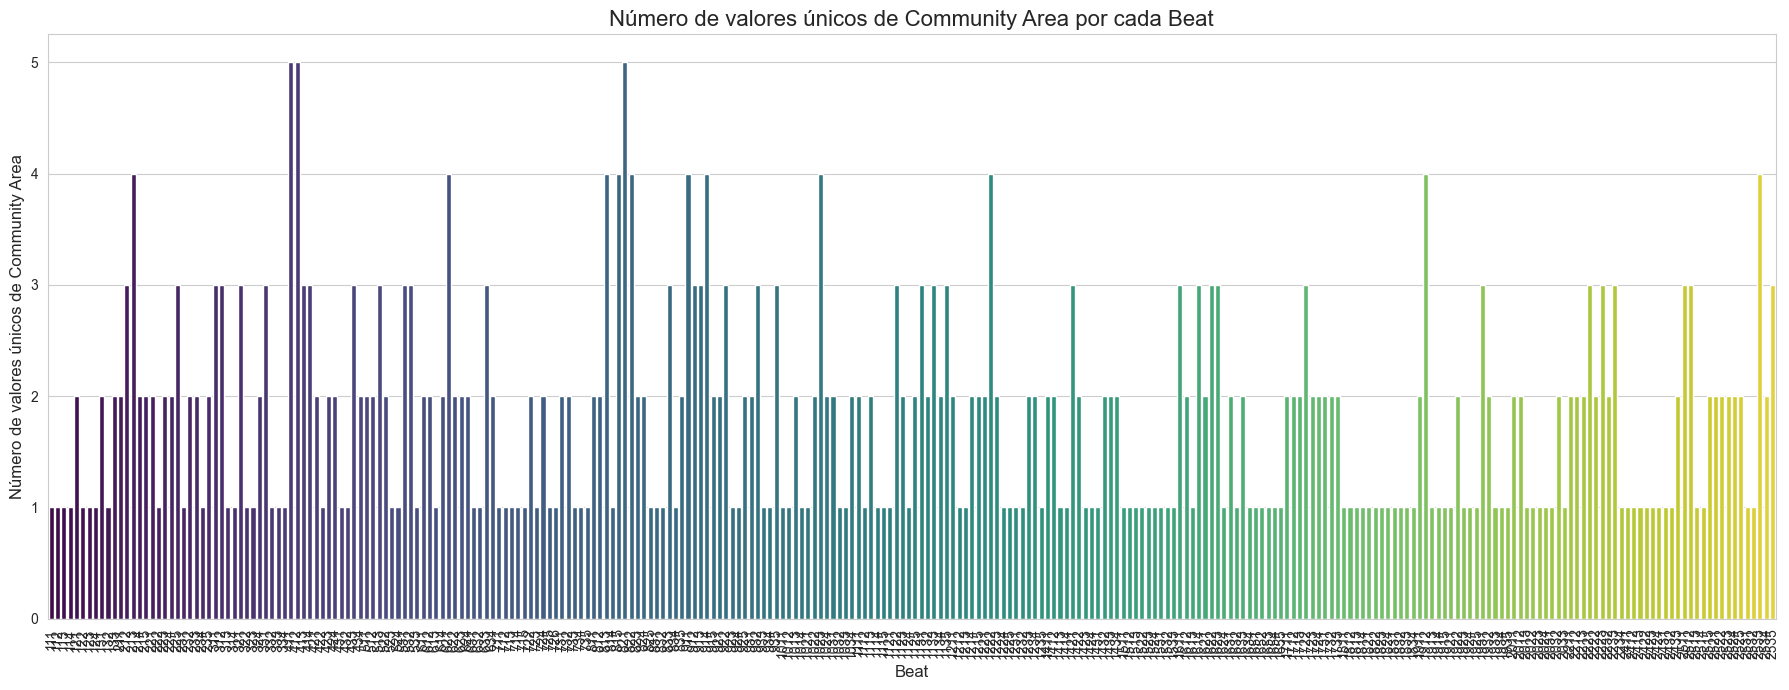



Calculando variabilidad para 'Ward' por cada 'Beat'...


/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/3584875871.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='viridis')


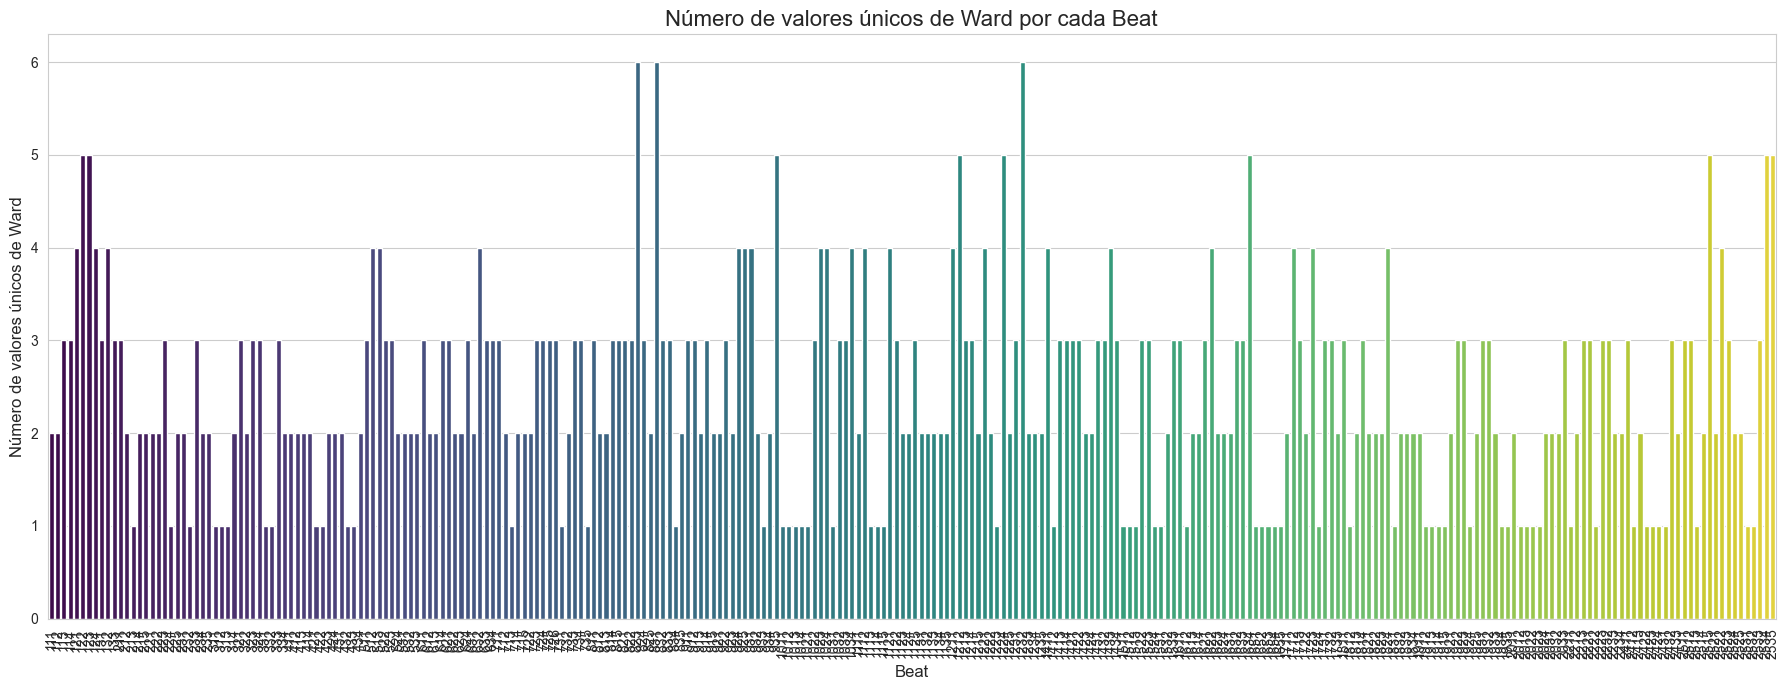



Calculando variabilidad para 'District' por cada 'Beat'...


/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/3584875871.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='viridis')


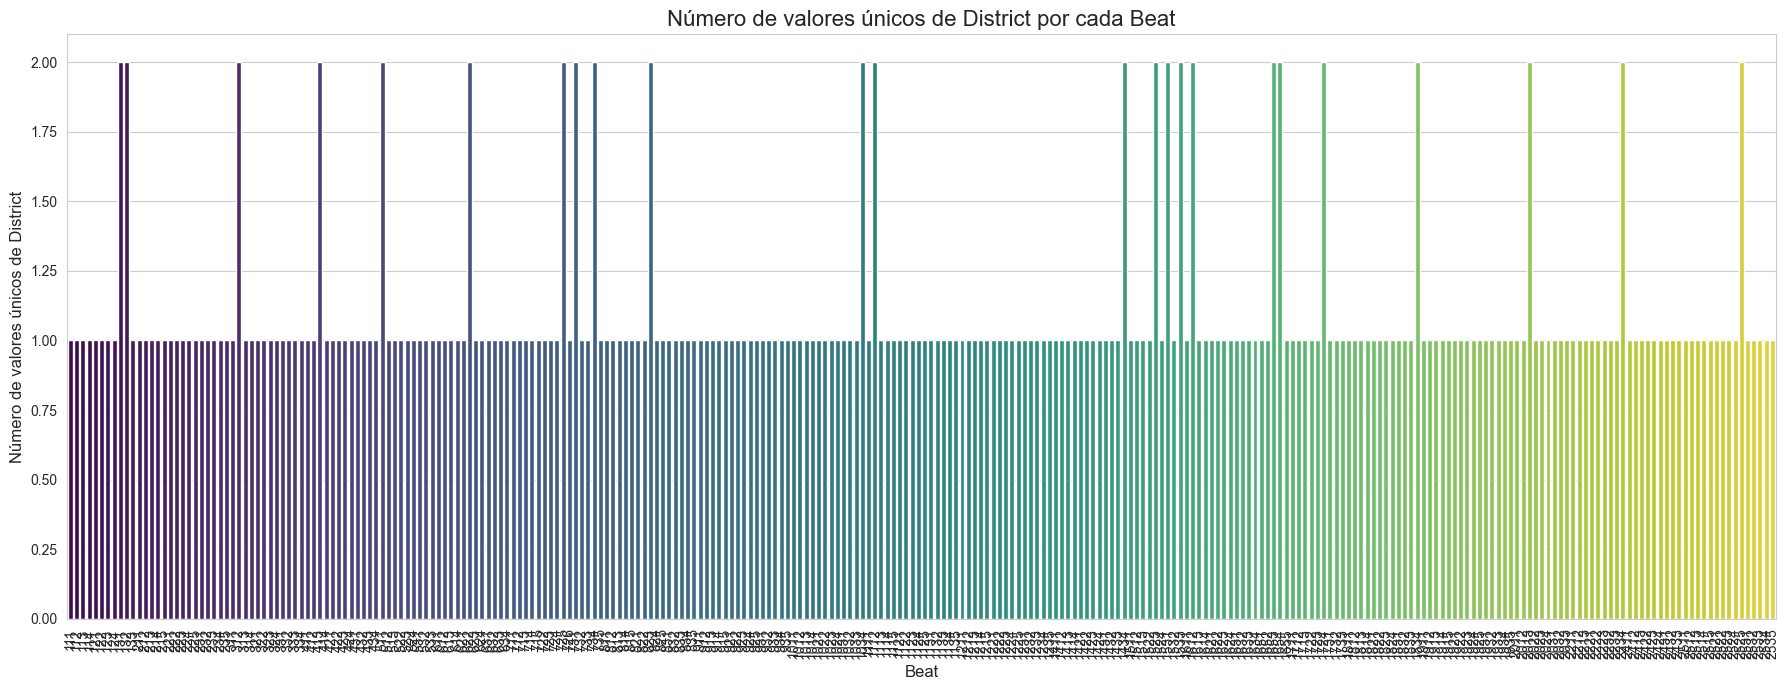

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Lista de pares de variables para analizar la variabilidad
variability_pairs = [
    ('Beat', 'Community Area'),
    ('Beat', 'Ward'),
    ('Beat', 'District')
]

for col1, col2 in variability_pairs:
    print(f"Calculando variabilidad para '{col2}' por cada '{col1}'...")

    # Calcular el número de valores únicos de col2 para cada valor de col1
    # Usamos dropna=False para incluir NaN si es relevante, aunque para conteo de únicos se suele omitir.
    # Si hay NaN en col2, se contarán como un valor único. Si no queremos eso, se podría usar .dropna()
    unique_counts = df.groupby(col1)[col2].nunique().sort_values(ascending=False)

    # Filtrar para beats con más de 1 valor único para una mejor visualización si es necesario
    #unique_counts = unique_counts[unique_counts > 1]

    if not unique_counts.empty:
        plt.figure(figsize=(18, 7))
        sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='viridis')
        plt.title(f'Número de valores únicos de {col2} por cada {col1}', fontsize=16)
        plt.xlabel(col1, fontsize=12)
        plt.ylabel(f'Número de valores únicos de {col2}', fontsize=12)
        plt.xticks(rotation=90) # Rotar etiquetas para mejor legibilidad
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron datos para calcular la variabilidad de '{col2}' por '{col1}'.")
    print("\n" + "="*50 + "\n") # Separador entre gráficos

### Faltantes de localización (MAR)

**Análisis**: Los faltantes en las variables geográficas (Community Area, Ward, X Coordinate, Y Coordinate, Latitude, Longitude, Location) son MAR (Missing At Random). Observamos que muchos Beats tienen una relación casi unívoca con Community Area, lo que permite imputar Community Area faltante usando la moda de Community Area para cada Beat.

**Decisión de variables a conservar**: Decidimos conservar únicamente **Beat** y **Community Area** como variables de importancia geográfica:
- **Beat**: Para granularidad en la detección de patrones por barrio pequeño
- **Community Area**: Para interpretación semántica a nivel de distrito

**Variables a eliminar**: El resto de las variables geográficas no aportan valor ante la presencia de estas dos: Location, Latitude, Longitude, X Coordinate, Y Coordinate, District, Ward y Block.

**Tratamiento de faltantes en Community Area**: Los valores faltantes se imputarán con la moda de Community Area de las filas que comparten el mismo Beat. Esta imputación se ajustará usando únicamente el conjunto de entrenamiento (ver Sección 3) para evitar data leakage.

### Propuesta de eliminación de variables geográficas redundantes

En base al análisis anterior, se propone:

**Conservar:**
- `Beat`
- `Community Area`

**Eliminar:**
- `Location`
- `Latitude`, `Longitude`
- `X Coordinate`, `Y Coordinate`
- `District`
- `Ward`
- `Block`

**Justificación**: Beat y Community Area capturan la información geográfica necesaria con diferentes niveles de granularidad. Las demás variables son redundantes o derivadas de estas dos.

**Aplicación**: Esta eliminación se aplicará en la Sección 3 (Preprocesamiento), después de aplicar el tratamiento de duplicados.

/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/3929129715.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=primary_type_counts_null.index, y=primary_type_counts_null.values, palette='viridis')


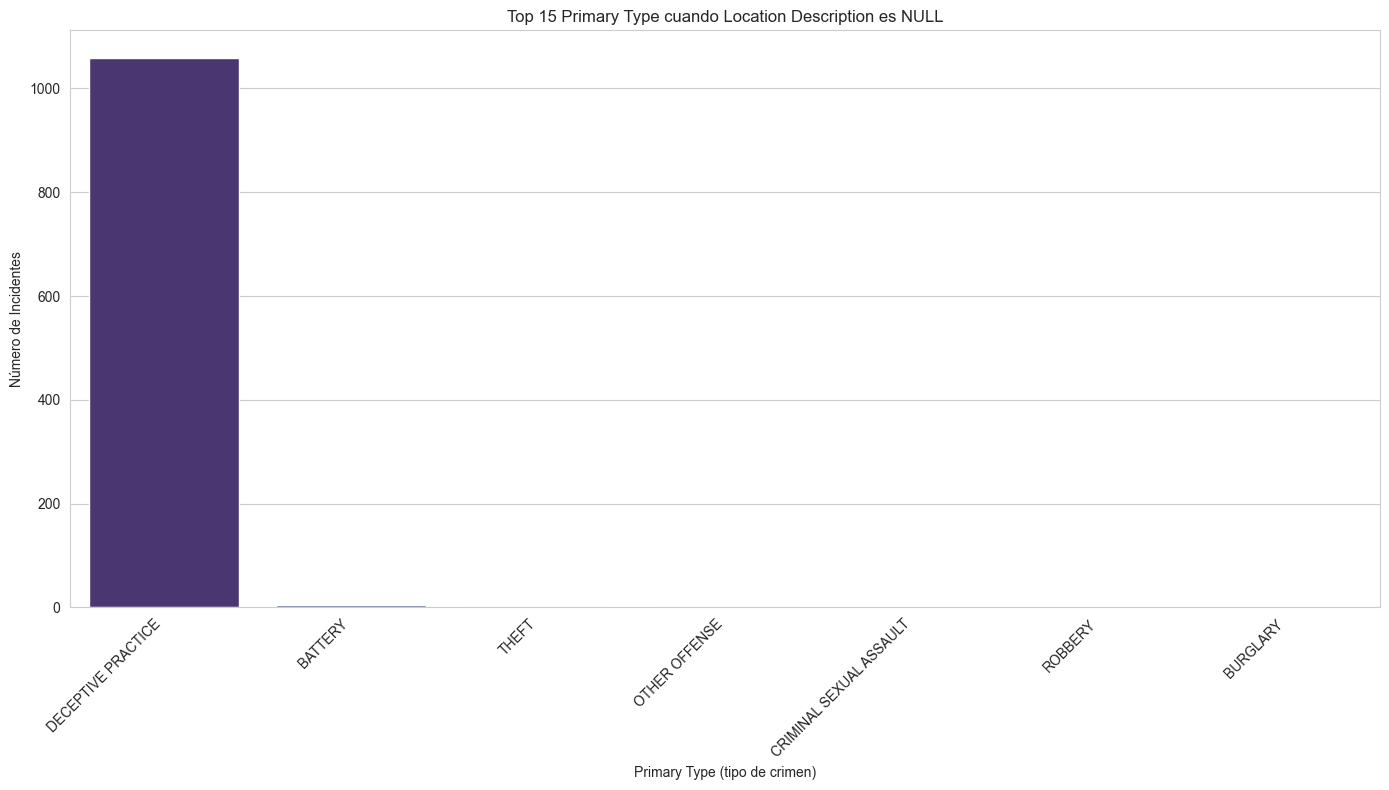

/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/3929129715.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=description_counts_null.index, y=description_counts_null.values, palette='viridis')


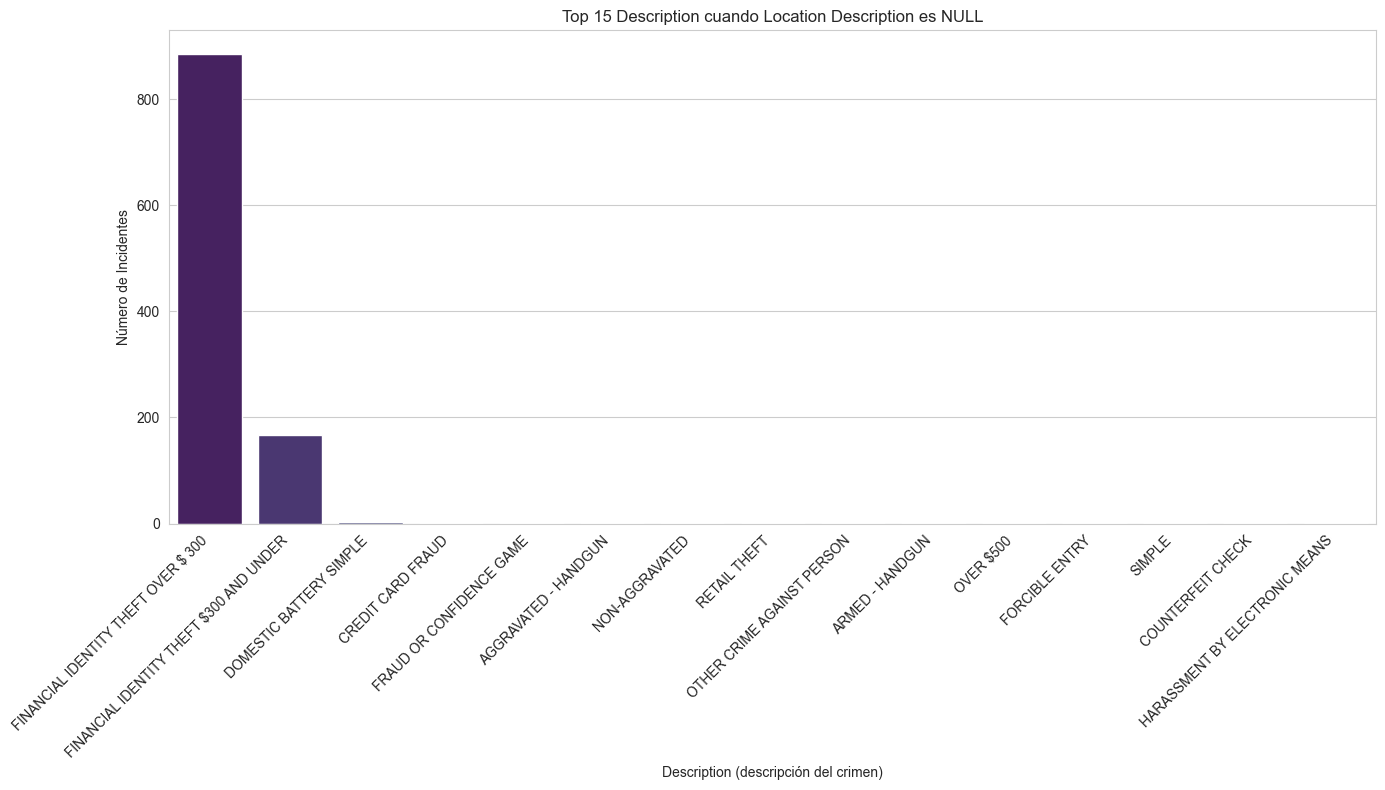

In [128]:
# Filtrar el DataFrame para las filas donde 'Location Description' es null / NaN
df_null_location = df[df['Location Description'].isna()]

# --- Gráfico 1: Top 15 Primary Type ---
primary_type_counts_null = df_null_location['Primary Type'].value_counts().nlargest(15)

plt.figure(figsize=(14, 8))
sns.barplot(x=primary_type_counts_null.index, y=primary_type_counts_null.values, palette='viridis')
plt.title('Top 15 Primary Type cuando Location Description es NULL')
plt.xlabel('Primary Type (tipo de crimen)')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Gráfico 2: Top 15 Description ---
description_counts_null = df_null_location['Description'].value_counts().nlargest(15)

plt.figure(figsize=(14, 8))
sns.barplot(x=description_counts_null.index, y=description_counts_null.values, palette='viridis')
plt.title('Top 15 Description cuando Location Description es NULL')
plt.xlabel('Description (descripción del crimen)')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Faltantes en Location Description (Faltante estructural - MNAR)

**Análisis**: Location Description presenta valores faltantes que están asociados a la ausencia de una topología física del crimen. Al analizar su relación con Primary Type y Description, notamos que semánticamente estas filas corresponden a crímenes sin ubicación física específica, como estafas telefónicas o virtuales (principalmente "financial identity theft").

**Tipo de faltante**: MNAR (Missing Not At Random) - Faltante estructural. La ausencia de valor es informativa por sí misma: indica que el crimen ocurrió en un contexto virtual.

**Decisión de tratamiento**: Se creará un nuevo valor categórico `'VIRTUAL'` para Location Description, que completa esta ausencia de forma semánticamente significativa. Al tratarse de un valor constante, la imputación se aplicará de forma idéntica sobre train y test en la Sección 3 (Preprocesamiento).

### Correlacion y variabilidad entre variables categoricas

In [129]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations

# Define the list of variables for Cramér's V analysis
variables_for_cramers_v = [
    'IUCR', 'Block', 'Primary Type', 'Description', 'FBI Code',
    'Domestic', 'Arrest', 'Location Description', 'Beat', 'Ward', 'Community Area'
]

# Create a copy of the relevant columns from the original 'df' DataFrame
# and convert suitable numerical/boolean columns to 'category' type
# to ensure they are treated as discrete categories for the calculation.
df_cramer_analysis = df[variables_for_cramers_v].copy()

for col in ['Beat', 'Ward', 'Community Area', 'Domestic', 'Arrest']:
    if col in df_cramer_analysis.columns:
        df_cramer_analysis[col] = df_cramer_analysis[col].astype('category')

# Initialize a DataFrame to store Cramér's V values
cramers_v_matrix = pd.DataFrame(index=variables_for_cramers_v, columns=variables_for_cramers_v, dtype=float)

print("Calculando Cramér's V para pares de variables seleccionadas...")

# Calculate Cramér's V for all unique pairs of variables
for col1, col2 in combinations(variables_for_cramers_v, 2):
    # Create contingency table, dropping NaNs for accurate counts.
    # pd.crosstab by default excludes missing values.
    contingency_table = pd.crosstab(df_cramer_analysis[col1], df_cramer_analysis[col2])

    # Check for empty tables or tables with only one row/column after dropping NaNs
    if contingency_table.empty or min(contingency_table.shape) <= 1:
        cramers_v = 0.0 # If no variability or data, association is 0
    else:
        chi2, _, _, _ = chi2_contingency(contingency_table)
        n = contingency_table.sum().sum()
        r, k = contingency_table.shape # r = rows, k = columns

        # Handle cases where min(k-1, r-1) is zero to avoid division by zero
        min_dim = min(k - 1, r - 1)
        if min_dim == 0:
            cramers_v = 0.0
        else:
            phi2 = chi2 / n
            cramers_v = np.sqrt(phi2 / min_dim)

    # Store the value in the symmetric matrix
    cramers_v_matrix.loc[col1, col2] = cramers_v
    cramers_v_matrix.loc[col2, col1] = cramers_v # Since Cramér's V is symmetric

# Fill diagonal with 1.0 (a variable is perfectly associated with itself)
# (con pandas Copy-on-Write, .values es de solo lectura: asignamos por etiqueta)
for v in variables_for_cramers_v:
    cramers_v_matrix.loc[v, v] = 1.0

print("Tabla de Cramér's V (Fuerza de Asociación) entre las variables:")

# Define a function to highlight values
def highlight_strong_association(val):
    return 'font-weight: bold; color: green;' if val > 0.5 else ''

# Display the DataFrame with values greater than 0.5 highlighted using applymap
display(cramers_v_matrix.style.map(highlight_strong_association).format(precision=4))


Calculando Cramér's V para pares de variables seleccionadas...
Tabla de Cramér's V (Fuerza de Asociación) entre las variables:


,IUCR,Block,Primary Type,Description,FBI Code,Domestic,Arrest,Location Description,Beat,Ward,Community Area
IUCR,1.0000,0.3501,1.0000,1.0000,1.0000,0.7467,0.6628,0.1599,0.0706,0.0899,0.0847
Block,0.3501,1.0000,0.3931,0.3507,0.4083,0.4792,0.4292,0.4479,0.9641,0.9782,0.9926
Primary Type,1.0000,0.3931,1.0000,0.9671,0.8396,0.5216,0.5564,0.1963,0.1113,0.0685,0.0782
Description,1.0000,0.3507,0.9671,1.0000,0.9692,0.7359,0.6607,0.1590,0.0698,0.0889,0.0838
FBI Code,1.0000,0.4083,0.8396,0.9692,1.0000,0.5130,0.5562,0.2009,0.1170,0.0744,0.0842
Domestic,0.7467,0.4792,0.5216,0.7359,0.5130,1.0000,0.0128,0.4412,0.2133,0.1835,0.1943
Arrest,0.6628,0.4292,0.5564,0.6607,0.5562,0.0128,1.0000,0.1938,0.1710,0.1124,0.1357
Location Description,0.1599,0.4479,0.1963,0.1590,0.2009,0.4412,0.1938,1.0000,0.1316,0.1155,0.1148
Beat,0.0706,0.9641,0.1113,0.0698,0.1170,0.2133,0.1710,0.1316,1.0000,0.8332,0.8572
Ward,0.0899,0.9782,0.0685,0.0889,0.0744,0.1835,0.1124,0.1155,0.8332,1.0000,0.6878


### Como la mayoria de estas variables categoricas tienen muchos valores posibles decidimos quedarnos con el analisis de cramer V y hacer un analisis grafico de domestic y arrest con las variables topologicas de crimen, dado que con las mismas podriamos interpretar algo del headmap

Generando un dashboard con gráficos de pirámide poblacional:


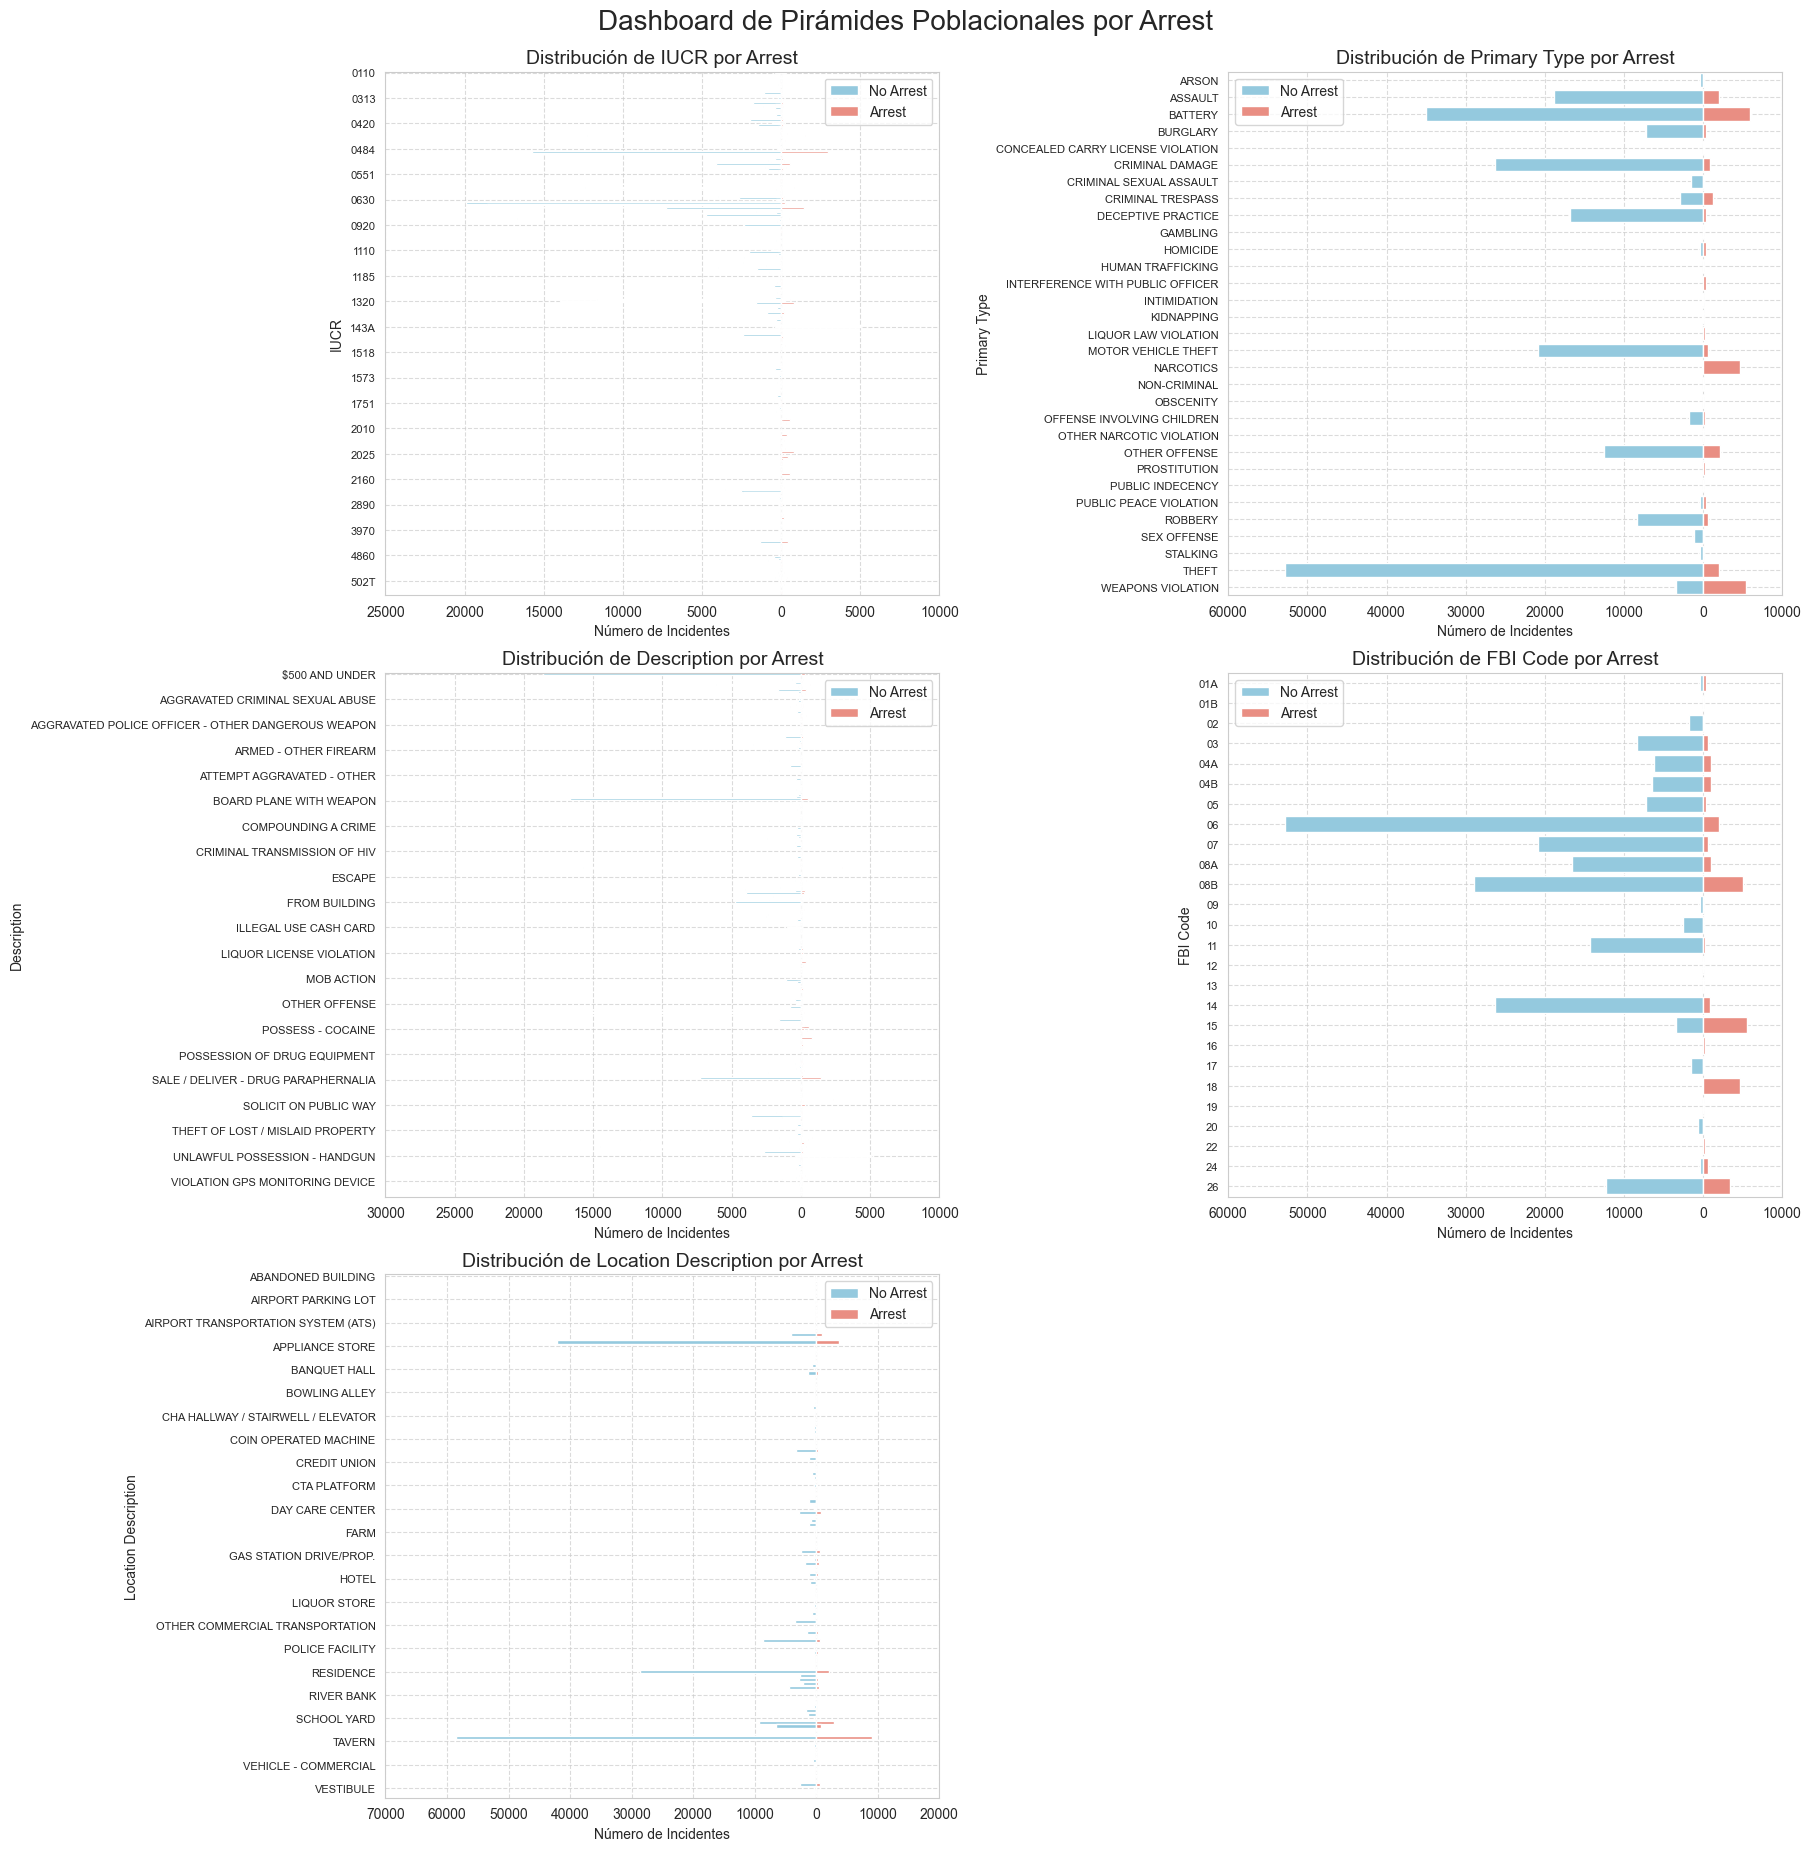


Se ha generado un dashboard con pirámides poblacionales para las variables solicitadas.


In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generando un dashboard con gráficos de pirámide poblacional:")

# List of variables to be plotted against 'Arrest'
var1_list = ['IUCR', 'Primary Type', 'Description', 'FBI Code', 'Location Description']
var2 = 'Arrest' # The binary variable for the pyramid

# Determine grid size for subplots (e.g., 3 rows, 2 columns for 5 plots)
num_plots = len(var1_list)
rows = int(np.ceil(num_plots / 2))
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows), constrained_layout=True)
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, var1 in enumerate(var1_list):
    if var1 in df.columns and var2 in df.columns:
        # Create the contingency table
        contingency_table = pd.crosstab(df[var1], df[var2], dropna=False)

        # Ensure both True and False columns exist, filling missing with 0
        if True not in contingency_table.columns:
            contingency_table[True] = 0
        if False not in contingency_table.columns:
            contingency_table[False] = 0

        # Ensure consistent order of columns using .reindex for clarity
        # This explicitly tells pandas to reorder columns by label [False, True]
        contingency_table = contingency_table.reindex(columns=[False, True], fill_value=0)

        ax = axes[i]

        # Get counts for 'False' (e.g., No Arrest) and 'True' (e.g., Arrest)
        counts_false = contingency_table[False]
        counts_true = contingency_table[True]

        # To make it a 'pyramid' style, one side will be negative values
        counts_false_neg = -counts_false

        # Plot bars for 'False' (e.g., No Arrest)
        sns.barplot(x=counts_false_neg.values, y=counts_false_neg.index, color='skyblue', ax=ax, label=f'No {var2}')

        # Plot bars for 'True' (e.g., Arrest)
        sns.barplot(x=counts_true.values, y=counts_true.index, color='salmon', ax=ax, label=var2)

        ax.set_title(f'Distribución de {var1} por {var2}', fontsize=14)
        ax.set_xlabel('Número de Incidentes', fontsize=10)
        ax.set_ylabel(var1, fontsize=10)
        ax.tick_params(axis='y', labelsize=8)

        # Adjust x-axis ticks to show absolute values
        ticks_loc = ax.get_xticks()
        ax.set_xticks(ticks_loc)
        ax.set_xticklabels([f'{abs(x):.0f}' for x in ticks_loc])

        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)

        # Limit y-axis labels to prevent clutter if too many categories
        if len(counts_false.index) > 20:
            # Dynamically adjust yticks based on the number of categories
            step = max(1, len(counts_false.index) // 20) # ensure at least 1
            ax.set_yticks(np.arange(0, len(counts_false.index), step))

    else:
        axes[i].set_visible(False) # Hide empty subplot if columns are missing
        print(f"Una o ambas columnas '{var1}', '{var2}' no se encontraron en el DataFrame para el plot {i+1}.")

# Hide any remaining empty subplots if num_plots is odd
for j in range(num_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Dashboard de Pirámides Poblacionales por {var2}', fontsize=20, y=1.02) # Master title for the dashboard
plt.show()

print("\nSe ha generado un dashboard con pirámides poblacionales para las variables solicitadas.")

Generando un dashboard con gráficos de pirámide poblacional:


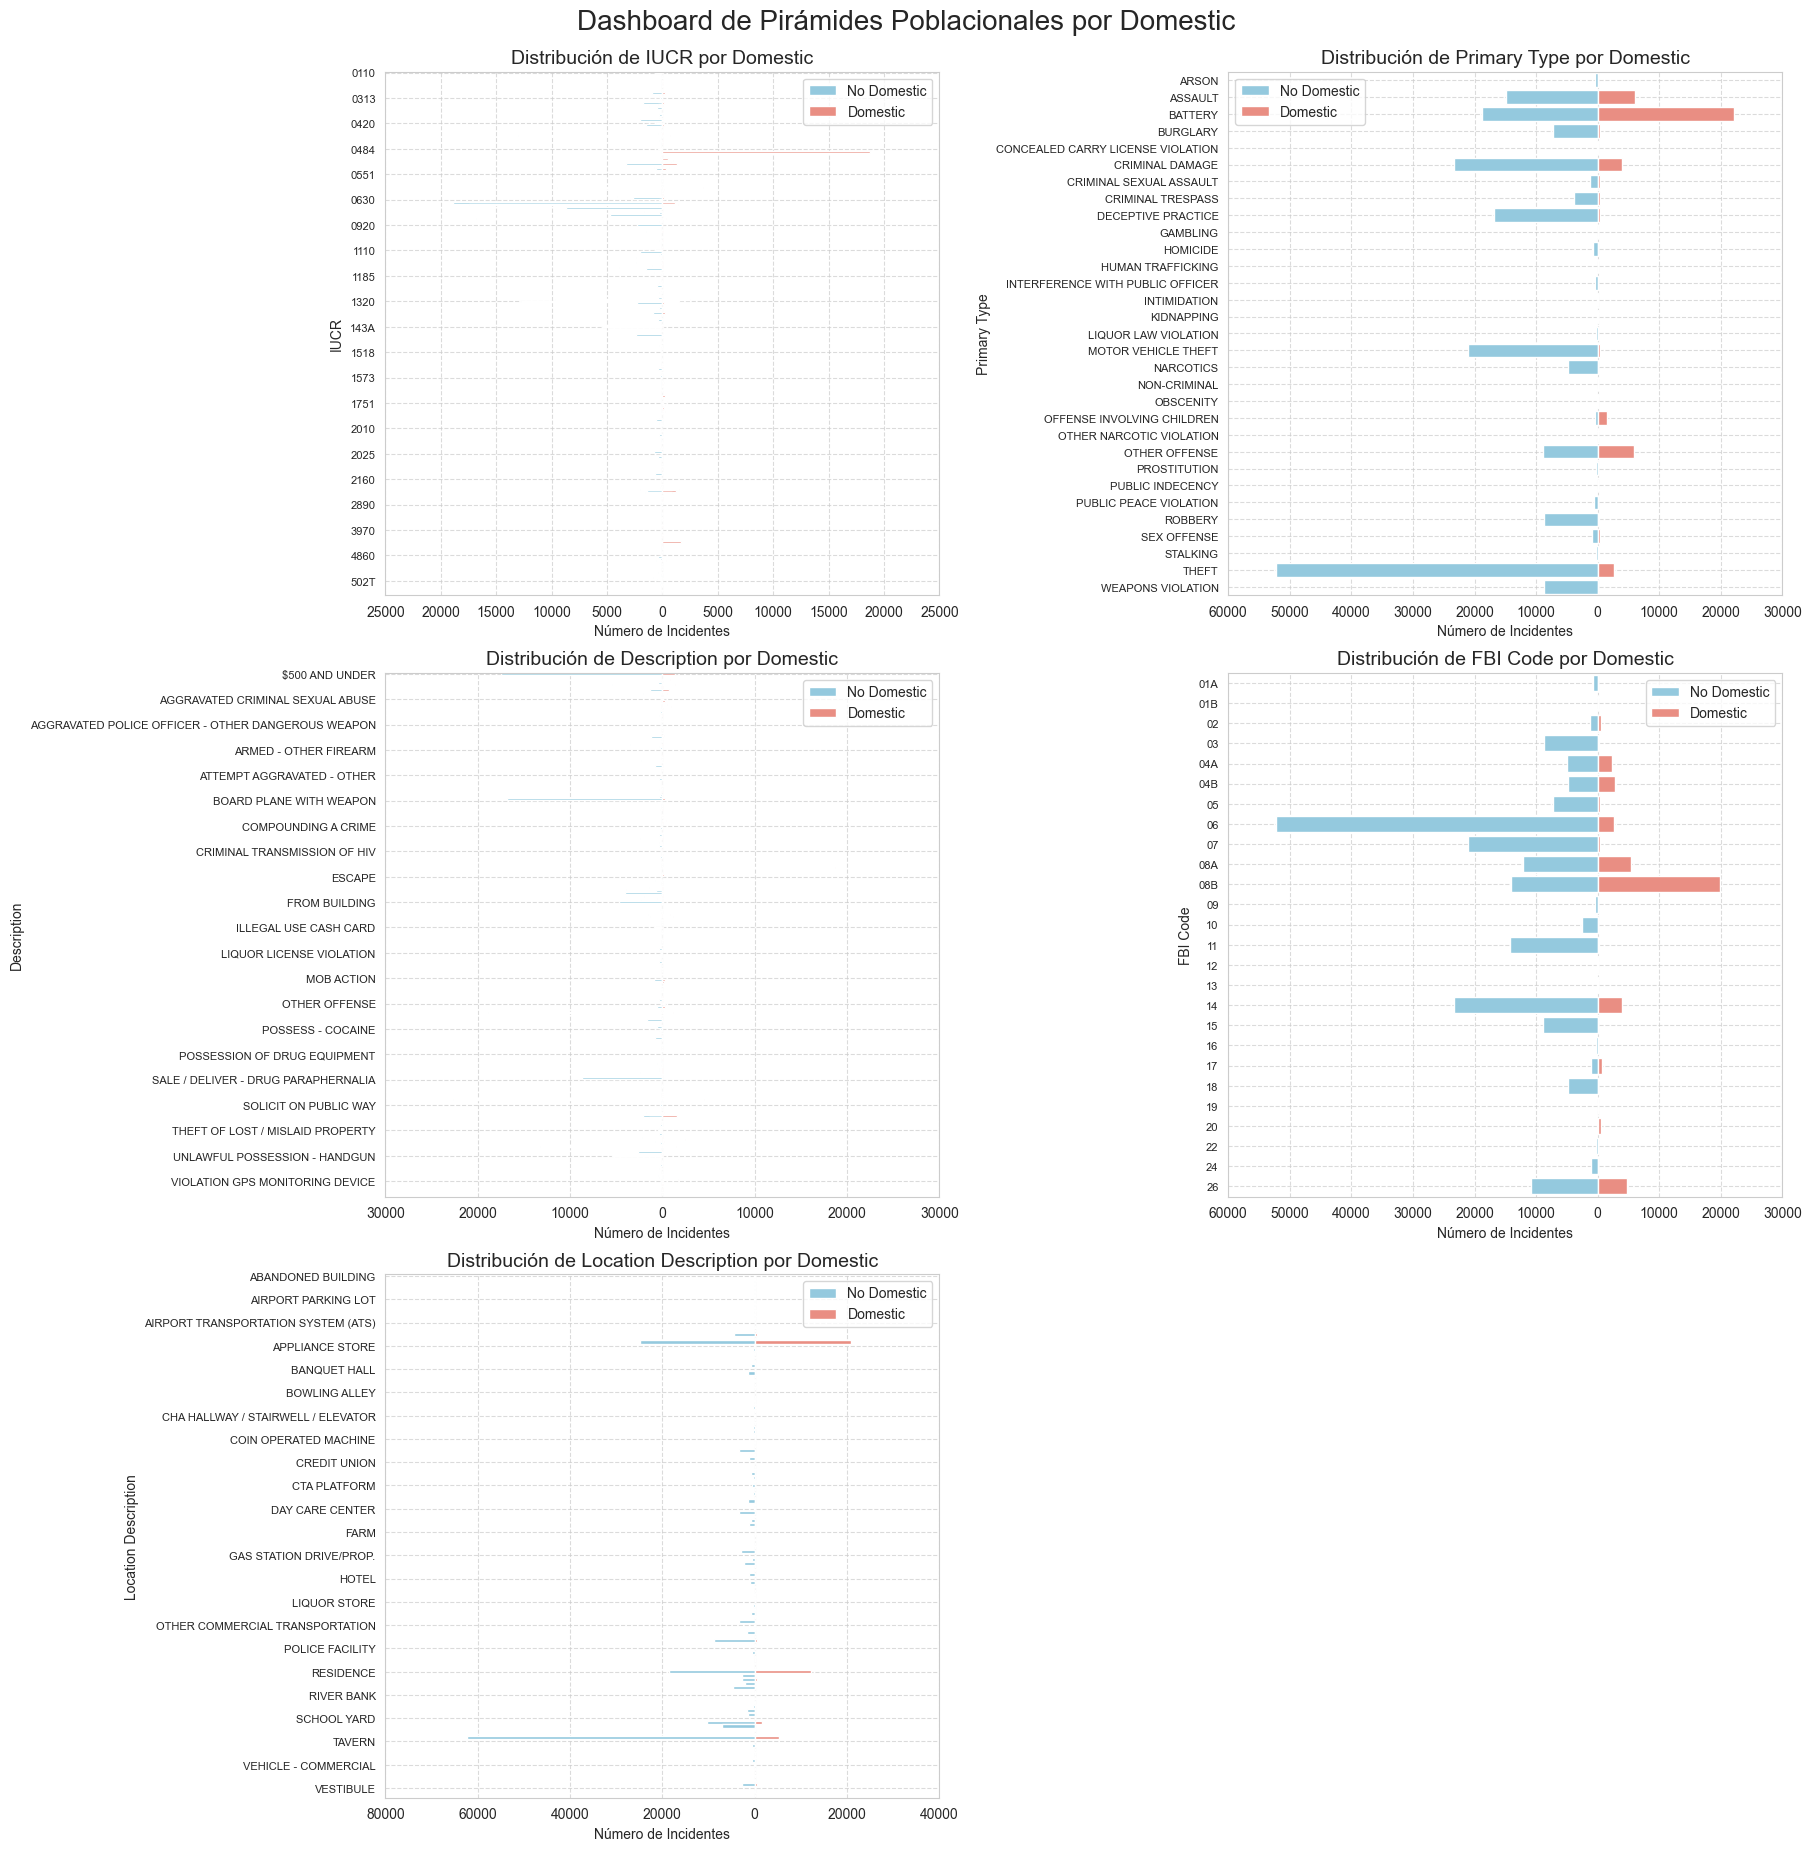


Se ha generado un dashboard con pirámides poblacionales para las variables solicitadas.


In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generando un dashboard con gráficos de pirámide poblacional:")

# List of variables to be plotted against 'Domestic'
var1_list = ['IUCR', 'Primary Type', 'Description', 'FBI Code', 'Location Description']
var2 = 'Domestic' # The binary variable for the pyramid

# Determine grid size for subplots (e.g., 3 rows, 2 columns for 5 plots)
num_plots = len(var1_list)
rows = int(np.ceil(num_plots / 2))
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows), constrained_layout=True)
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, var1 in enumerate(var1_list):
    if var1 in df.columns and var2 in df.columns:
        # Create the contingency table
        contingency_table = pd.crosstab(df[var1], df[var2], dropna=False)

        # Ensure both True and False columns exist, filling missing with 0
        if True not in contingency_table.columns:
            contingency_table[True] = 0
        if False not in contingency_table.columns:
            contingency_table[False] = 0

        # Ensure consistent order of columns using .reindex for clarity
        # This explicitly tells pandas to reorder columns by label [False, True]
        contingency_table = contingency_table.reindex(columns=[False, True], fill_value=0)

        ax = axes[i]

        # Get counts for 'False' (e.g., Non-Domestic) and 'True' (e.g., Domestic)
        counts_false = contingency_table[False]
        counts_true = contingency_table[True]

        # To make it a 'pyramid' style, one side will be negative values
        counts_false_neg = -counts_false

        # Plot bars for 'False' (e.g., Non-Domestic)
        sns.barplot(x=counts_false_neg.values, y=counts_false_neg.index, color='skyblue', ax=ax, label=f'No {var2}')

        # Plot bars for 'True' (e.g., Domestic)
        sns.barplot(x=counts_true.values, y=counts_true.index, color='salmon', ax=ax, label=var2)

        ax.set_title(f'Distribución de {var1} por {var2}', fontsize=14)
        ax.set_xlabel('Número de Incidentes', fontsize=10)
        ax.set_ylabel(var1, fontsize=10)
        ax.tick_params(axis='y', labelsize=8)

        # Adjust x-axis ticks to show absolute values
        ticks_loc = ax.get_xticks()
        ax.set_xticks(ticks_loc)
        ax.set_xticklabels([f'{abs(x):.0f}' for x in ticks_loc])

        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)

        # Limit y-axis labels to prevent clutter if too many categories
        if len(counts_false.index) > 20:
            # Dynamically adjust yticks based on the number of categories
            step = max(1, len(counts_false.index) // 20) # ensure at least 1
            ax.set_yticks(np.arange(0, len(counts_false.index), step))

    else:
        axes[i].set_visible(False) # Hide empty subplot if columns are missing
        print(f"Una o ambas columnas '{var1}', '{var2}' no se encontraron en el DataFrame para el plot {i+1}.")

# Hide any remaining empty subplots if num_plots is odd
for j in range(num_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Dashboard de Pirámides Poblacionales por {var2}', fontsize=20, y=1.02) # Master title for the dashboard
plt.show()

print("\nSe ha generado un dashboard con pirámides poblacionales para las variables solicitadas.")

### Conclusión comparación de variables categoricas de topologias del crimen y los features: Arrest y Domestic

Si bien podemos determinar que no hay una relación concluyente entre estos cruces de variables si podemos concluir que:

1 - hay un gran desbalance en las variables de topologias de un crimen (hay tipos de crimenes que ocurren mucho mas que otros)

2 - hay un gran desbalance de reportes no arrestados por sobre los arrestados

3 - hay un gran desbalance de crimenes no domesticos por sobre los domesticos

4 - dentro de los crimenes domesticos hay una topologia del crimen mucho mas presente pero, dado que hay muchas otras topologias donde esta relación no es concluyente, no es prudente tomar alguna acción al respecto

### Nota sobre Desbalance en Variables Categóricas No-Target

**Importante:** El desbalance observado en las variables `Arrest`, `Domestic` y otras variables categóricas (Location Description, Description, etc.) **no requiere tratamiento** porque:

1. **No son la variable target**: el desbalance que nos interesa corregir es el de `Primary Type` (variable a predecir), no el de las features.
2. **Reflejan la realidad del fenómeno**: el desbalance en estas variables es intrínseco a la naturaleza de los datos (ej: la mayoría de los crímenes NO terminan en arresto, lo cual es información valiosa para el modelo).
3. **Son features predictivos legítimos**: un modelo debe aprender estas distribuciones reales para hacer predicciones precisas.

Por ejemplo, si el 88% de los crímenes no resultan en arresto, este patrón es información útil que el modelo debe aprender, no un problema a corregir.

Generando un heatmap de la relación entre 'Domestic' y 'Arrest':
Matriz de Contingencia:


Arrest,False,True
Domestic,,
False,172511,22570
True,39327,5683


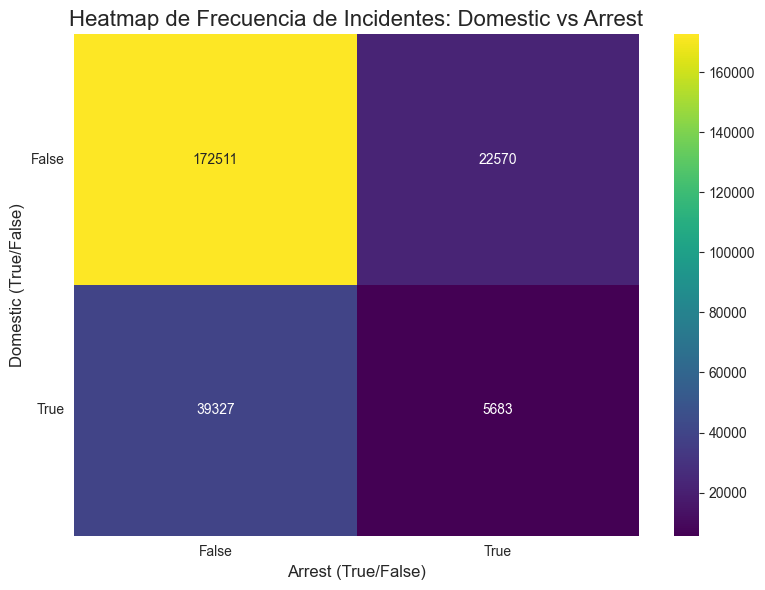

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando un heatmap de la relación entre 'Domestic' y 'Arrest':")

# Create the contingency table
contingency_table = pd.crosstab(df['Domestic'], df['Arrest'])

# Display the contingency table (optional, for raw numbers)
print("Matriz de Contingencia:")
display(contingency_table)

# Visualize the contingency table as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='viridis')
plt.title('Heatmap de Frecuencia de Incidentes: Domestic vs Arrest', fontsize=16)
plt.xlabel('Arrest (True/False)', fontsize=12)
plt.ylabel('Domestic (True/False)', fontsize=12)
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Calculando variabilidad para 'FBI Code' por cada 'IUCR'...


/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/1167218866.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='viridis')


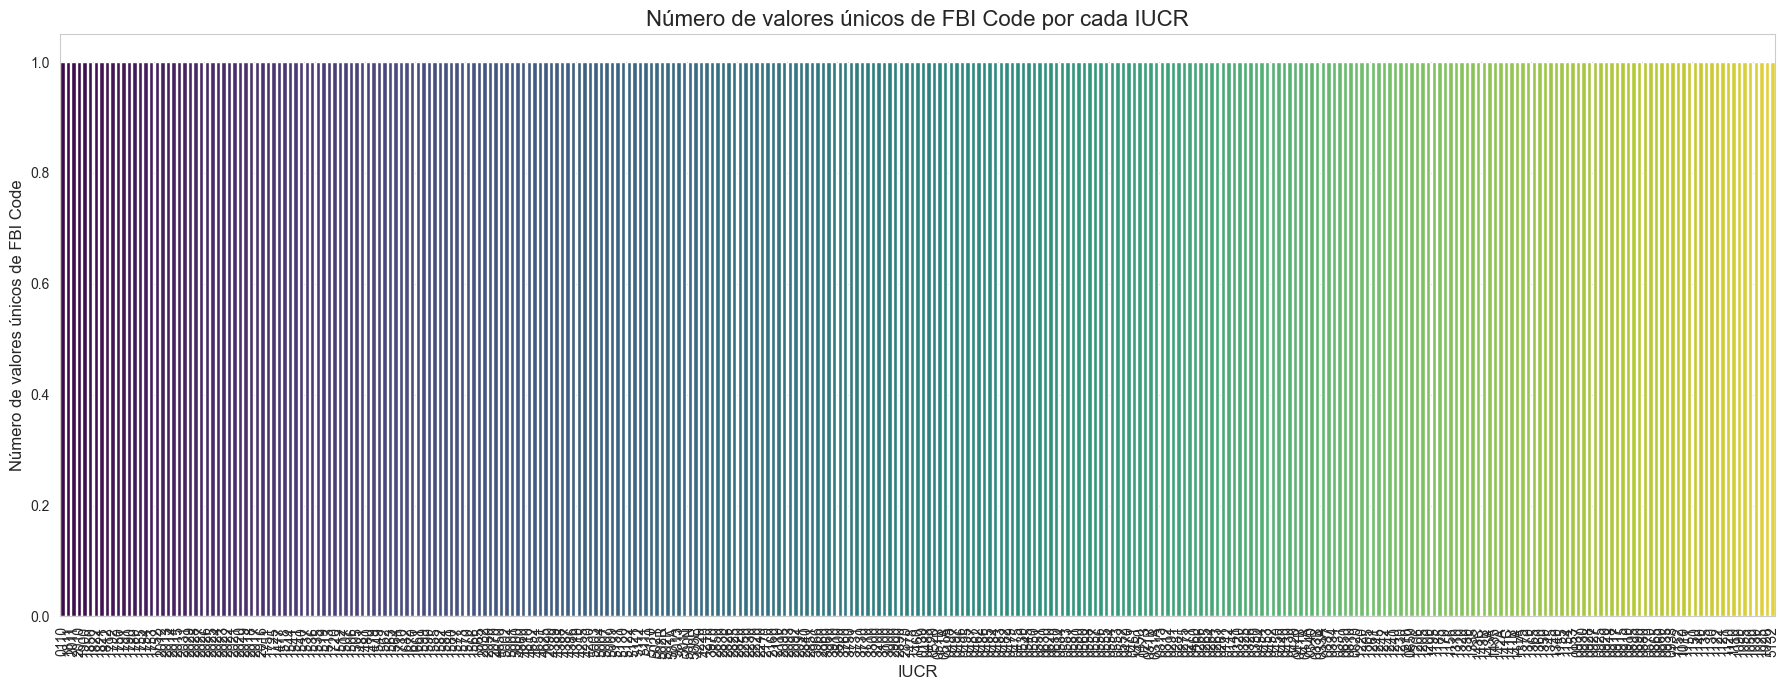

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Lista de pares de variables para analizar la variabilidad
variability_pairs = [
    ('IUCR', 'FBI Code'),
]

for col1, col2 in variability_pairs:
    print(f"Calculando variabilidad para '{col2}' por cada '{col1}'...")

    # Calcular el número de valores únicos de col2 para cada valor de col1
    # Usamos dropna=False para incluir NaN si es relevante, aunque para conteo de únicos se suele omitir.
    # Si hay NaN en col2, se contarán como un valor único. Si no queremos eso, se podría usar .dropna()
    unique_counts = df.groupby(col1)[col2].nunique().sort_values(ascending=False)

    # Filtrar para beats con más de 1 valor único para una mejor visualización si es necesario
    #unique_counts = unique_counts[unique_counts > 1]

    if not unique_counts.empty:
        plt.figure(figsize=(18, 7))
        sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='viridis')
        plt.title(f'Número de valores únicos de {col2} por cada {col1}', fontsize=16)
        plt.xlabel(col1, fontsize=12)
        plt.ylabel(f'Número de valores únicos de {col2}', fontsize=12)
        plt.xticks(rotation=90) # Rotar etiquetas para mejor legibilidad
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron datos para calcular la variabilidad de '{col2}' por '{col1}'.")
    print("\n" + "="*50 + "\n") # Separador entre gráficos

### Reducción de variables redundantes: FBI Code e IUCR

**Análisis de relación FBI Code - IUCR:**
Encontramos una relación de dependencia entre FBI Code e IUCR: un FBI Code puede tener muchos IUCR, pero un código IUCR pertenece a un único FBI Code, por lo que podríamos quedarnos solo con IUCR.

**Análisis de IUCR para evitar Data Leakage:**
Aunque IUCR contiene información sobre el tipo de crimen, existe una relación casi determinística entre IUCR y Primary Type (variable target). Un código IUCR específico está fuertemente asociado a un tipo primario de crimen, lo que significa que usar IUCR como feature introduciría **data leakage**: el modelo "memorizaría" la asociación entre códigos IUCR y tipos de crimen en lugar de aprender patrones generalizables a partir de las características contextuales del incidente.

**Decisión de tratamiento**: Eliminar tanto FBI Code como IUCR del conjunto de features.

**Conservación de Description:**
También notamos que la mayoría de los Primary Type tienen una relación 1 a 1 con Description. Sin embargo, encontramos algunos casos particulares en los que una Description pertenece a más de un Primary Type, como el caso de "Aggravated", que puede pertenecer tanto a "Robbery" como a "Kidnapping", "Arson" y "Stalking". Por más que sean pocos casos (13 descriptions en total), eliminar la variable implicaría pérdida de información, por lo que decidimos mantenerla.

**Aplicación**: Esta eliminación se aplicará en la Sección 3 (Preprocesamiento).

### Conclusiones del EDA y Propuestas de Limpieza

**Hallazgos principales:**
- El dataset contiene 240,091 crímenes reportados en Chicago durante 2022.
- Se identificaron 47 duplicados por Case Number que serán eliminados.
- Se detectaron valores faltantes en variables geográficas (MAR) y Location Description (MNAR - faltante estructural).
- Se identificaron variables redundantes que introducen data leakage (IUCR, FBI Code).

**Propuestas de tratamiento (a aplicar en Sección 3):**
1. **Duplicados**: Eliminar duplicados conservando el registro con último `Updated On`
2. **Variables geográficas**: Conservar solo Beat y Community Area; eliminar Location, Latitude, Longitude, Coordenadas X/Y, District, Ward, Block
3. **Community Area faltante**: Imputar con moda por Beat (ajustada solo en train)
4. **Location Description faltante**: Completar con valor 'VIRTUAL' (faltante estructural)
5. **IUCR y FBI Code**: Eliminar para evitar data leakage con Primary Type
6. **Description**: Conservar por aportar información diferencial en casos específicos
7. **Outliers y escalado**: No se requiere tratamiento (todas las features son categóricas)

## 2. El problema
✅ Describir el problema de clasificación o de regresión.

✅ Definir la variable target.

El problema que abordaremos es un problema de **clasificación multiclase**, donde el objetivo es predecir el tipo principal de crimen (`Primary Type`) basándose en las características del incidente reportado.


Dicho esto, la variable target seleccionada es `Primary Type`. Esta variable representa la clasificación general del crimen (e.g., THEFT, BATTERY, CRIMINAL DAMAGE, etc.).

**Justificación:**

*   **Relevancia:** Predecir el `Primary Type` es fundamental para entender la naturaleza de la criminalidad en Chicago y puede ser utilizado por las fuerzas del orden para asignar recursos de manera más efectiva, identificar tendencias delictivas y desarrollar estrategias de prevención.
*   **Granularidad:** Aunque existen otras variables relacionadas con el tipo de crimen (como `Description` o `IUCR`), `Primary Type` ofrece un nivel de granularidad adecuado. Es lo suficientemente específica para ser informativa, pero no tan detallada como `Description` que podría resultar en un número excesivo de clases y problemas de escasez de datos para algunas categorías. `IUCR` es un código alfanumérico que requiere una decodificación para su interpretación, mientras que `Primary Type` es directamente interpretable.

## 3. Preprocesamiento y limpieza del dataset
✅ Realizar una limpieza general del dataset, eliminando o corrigiendo datos
inconsistentes o irrelevantes.

✅ Realizar el split del dataset (ej: train y test).

✅ Identificar y tratar los valores faltantes en el dataset.

✅  Detectar y manejar los outliers utilizando técnicas estadísticas o visuales
apropiadas.

🟨 Escalar/normalizar los features. (no aplica para variables cateogricas)

### Aplicación de decisiones tomadas en el EDA

En base al análisis realizado en la Sección 1, aplicamos las siguientes transformaciones sobre el dataset original `df`:

In [134]:
# 1. Eliminación de duplicados por Case Number (decisión tomada en EDA)
print("1. Eliminación de duplicados por Case Number")
print(f"   Filas antes: {len(df)}")

# Asegurarse de que 'Updated On' es de tipo datetime
if not pd.api.types.is_datetime64_any_dtype(df['Updated On']):
    df['Updated On'] = pd.to_datetime(df['Updated On'], errors='coerce')

# Agrupar por 'Case Number' y quedarse con la fila con el 'Updated On' más reciente
df_cleaned = df.loc[df.groupby('Case Number')['Updated On'].idxmax()]
df = df_cleaned.copy()

print(f"   Filas después: {len(df)}")
print(f"   Duplicados eliminados: {240091 - len(df)}\n")

display(df.head())

1. Eliminación de duplicados por Case Number
   Filas antes: 240091
   Filas después: 240044
   Duplicados eliminados: 47



,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
79905,27048,HH186297,2022-09-09 16:29:00,009XX N PULASKI RD,0110,HOMICIDE,FIRST DEGREE MURDER,AUTO,False,False,...,37.0,23.0,01A,1149550.0,1906002.0,2022,2022-09-19 15:41:05,41.897989,-87.726164,POINT (-87.726164111 41.897988944)
107351,28608,HL577950,2022-08-03 05:23:00,069XX S DORCHESTER AVE,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,False,False,...,5.0,43.0,01A,1186742.0,1859060.0,2022,2025-02-21 15:40:32,41.768374,-87.591053,POINT (-87.591052758 41.76837389)
4050,28088,HM642363,2022-12-25 07:00:00,005XX W 56TH ST,0110,HOMICIDE,FIRST DEGREE MURDER,APARTMENT,True,False,...,20.0,68.0,01A,1173762.0,1867949.0,2022,2024-04-28 15:40:26,41.793064,-87.638367,POINT (-87.638367086 41.793063838)
160126,27090,HR468886,2022-05-20 03:55:00,052XX W WASHINGTON BLVD,0110,HOMICIDE,FIRST DEGREE MURDER,ALLEY,True,False,...,28.0,25.0,01A,1141510.0,1900251.0,2022,2022-12-30 15:40:22,41.882360,-87.755837,POINT (-87.755836794 41.882359845)
148697,26854,HV268664,2022-06-06 05:11:00,065XX S DREXEL AVE,0110,HOMICIDE,FIRST DEGREE MURDER,AUTO,False,False,...,20.0,42.0,01A,1183349.0,1861883.0,2022,2022-09-19 15:41:05,41.776200,-87.603402,POINT (-87.603401769 41.776200149)


In [135]:
# 2. Eliminación de variables geográficas redundantes (decisión tomada en EDA)
print("2. Eliminación de variables geográficas redundantes")

# Creamos una copia del DataFrame para el procesamiento posterior
df_post_null_process = df.copy()

# Eliminamos las variables geográficas redundantes (conservamos solo Beat y Community Area)
columns_to_drop = [
    'Location', 'Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate',
    'District', 'Ward', 'Block'
]
df_post_null_process = df_post_null_process.drop(columns=columns_to_drop, errors='ignore')

print(f"   Columnas eliminadas: {columns_to_drop}")
print(f"   Columnas restantes: {df_post_null_process.shape[1]}\n")

# Verificar faltantes pendientes de imputar
print("   Faltantes pendientes de imputar (se tratarán tras el split):")
display(df_post_null_process[['Community Area', 'Location Description']].isnull().sum().to_frame('Nulos'))

2. Eliminación de variables geográficas redundantes
   Columnas eliminadas: ['Location', 'Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate', 'District', 'Ward', 'Block']
   Columnas restantes: 14

   Faltantes pendientes de imputar (se tratarán tras el split):


,Nulos
Community Area,31
Location Description,1071


### 4. Limpieza final y preparación para el split

A partir del DataFrame `df_post_null_process` (ya con las decisiones del EDA aplicadas), realizamos la limpieza final orientada al modelado y el split en train/test.

**Columnas adicionales que eliminamos:**
- `ID`, `Case Number`, `Updated On`: identificadores / metadatos de trazabilidad, sin valor predictivo.
- `Year`: es constante (todos los registros son de 2022), por lo que su varianza es nula y no aporta información.

**Sobre el split:** usamos una partición **estratificada** por `Primary Type` (la variable target). Como las clases están desbalanceadas, la estratificación garantiza que la proporción de cada tipo de crimen se mantenga tanto en train como en test. Reservamos un 20% para test y fijamos `random_state` para que el experimento sea reproducible. **El split se hace antes de imputar** para que los parámetros de imputación se ajusten solo con train y no haya fuga de información.

In [136]:
# Limpieza final: eliminamos identificadores/metadatos y variables sin varianza
columns_to_drop_modeling = ['ID', 'Case Number', 'Updated On', 'Year']

df_post_null_process = df_post_null_process.drop(columns=columns_to_drop_modeling, errors='ignore')

print("Columnas eliminadas para el modelado:", columns_to_drop_modeling)
print("\nColumnas restantes:")
df_post_null_process.info()

Columnas eliminadas para el modelado: ['ID', 'Case Number', 'Updated On', 'Year']

Columnas restantes:
<class 'pandas.DataFrame'>
Index: 240044 entries, 79905 to 114780
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Date                  240044 non-null  datetime64[us]
 1   IUCR                  240044 non-null  string        
 2   Primary Type          240044 non-null  string        
 3   Description           240044 non-null  string        
 4   Location Description  238973 non-null  string        
 5   Arrest                240044 non-null  bool          
 6   Domestic              240044 non-null  bool          
 7   Beat                  240044 non-null  int64         
 8   Community Area        240013 non-null  float64       
 9   FBI Code              240044 non-null  string        
dtypes: bool(2), datetime64[us](1), float64(1), int64(1), string(5)
memory usage: 16.9 MB


**Outliers y escalado.** Una vez descartadas las variables geográficas (coordenadas, latitud/longitud) durante el tratamiento de faltantes y los identificadores en este paso, las features que quedan para el modelo son **categóricas** (`Location Description`, `Arrest`, `Domestic`) o códigos categóricos representados numéricamente (`Beat`, `Community Area`), además de `IUCR` y `Description`.

Por este motivo:
- **No aplicamos escalado/normalización:** no hay variables numéricas continuas cuya magnitud deba normalizarse; escalar códigos categóricos no tendría sentido.
- **No aplicamos tratamiento estadístico de outliers:** los outliers clásicos (valores extremos en variables continuas) no aplican a variables categóricas. Su equivalente —las categorías muy poco frecuentes— se analiza en la sección de Feature Engineering (desbalance de clases).

In [137]:
from sklearn.model_selection import train_test_split

target = 'Primary Type'

# Partición estratificada por la variable target (clases desbalanceadas)
df_train, df_test = train_test_split(
    df_post_null_process,
    test_size=0.2,
    random_state=42,
    stratify=df_post_null_process[target]
)

print(f"Tamaño train: {df_train.shape[0]} filas ({df_train.shape[0] / len(df_post_null_process):.0%})")
print(f"Tamaño test:  {df_test.shape[0]} filas ({df_test.shape[0] / len(df_post_null_process):.0%})")

# Verificar que la distribución de clases se conserva en ambos conjuntos
dist = pd.DataFrame({
    'train (%)': df_train[target].value_counts(normalize=True).mul(100).round(2),
    'test (%)':  df_test[target].value_counts(normalize=True).mul(100).round(2),
})
print("\nDistribución de 'Primary Type' (train vs test):")
display(dist)

Tamaño train: 192035 filas (80%)
Tamaño test:  48009 filas (20%)

Distribución de 'Primary Type' (train vs test):


,train (%),test (%)
Primary Type,,
ARSON,0.18,0.17
ASSAULT,8.67,8.67
BATTERY,17.07,17.07
BURGLARY,3.16,3.16
CONCEALED CARRY LICENSE VIOLATION,0.07,0.07
CRIMINAL DAMAGE,11.35,11.35
CRIMINAL SEXUAL ASSAULT,0.67,0.67
CRIMINAL TRESPASS,1.76,1.76
DECEPTIVE PRACTICE,7.16,7.16


### Tratamiento de faltantes (ajustado sobre train)

Para evitar fuga de información (*data leakage*), los parámetros de imputación se calculan **solo con el conjunto de entrenamiento** y luego se aplican tanto a train como a test:

- **Community Area (MAR):** se imputa con la moda de Community Area por Beat, calculada sobre train. Para los Beats que no aparezcan en train (o sin datos), se usa la moda global de train como respaldo.
- **Location Description (faltante estructural):** se completa con el valor constante `'VIRTUAL'`. Al ser una constante no requiere ajuste, pero igual se aplica de forma idéntica a ambos conjuntos.

In [138]:
# --- Community Area: moda por Beat, AJUSTADA SOLO CON TRAIN ---
beat_mode = (
    df_train.groupby('Beat')['Community Area']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
global_mode = df_train['Community Area'].mode().iloc[0]  # respaldo para Beats no vistos en train

def impute_community_area(frame):
    frame = frame.copy()
    fill = frame['Beat'].map(beat_mode).fillna(global_mode)
    frame['Community Area'] = frame['Community Area'].fillna(fill)
    return frame

df_train = impute_community_area(df_train)
df_test = impute_community_area(df_test)

# --- Location Description: faltante estructural -> valor constante 'VIRTUAL' ---
df_train['Location Description'] = df_train['Location Description'].fillna('VIRTUAL')
df_test['Location Description'] = df_test['Location Description'].fillna('VIRTUAL')

print("Nulos tras la imputación:")
display(pd.DataFrame({
    'train': df_train[['Community Area', 'Location Description']].isnull().sum(),
    'test':  df_test[['Community Area', 'Location Description']].isnull().sum(),
}))

Nulos tras la imputación:


,train,test
Community Area,0,0
Location Description,0,0


### Conclusiones del Split y Tratamiento de Faltantes

- Split estratificado 80/20 garantiza representatividad de todas las clases en train y test.
- Imputación de Community Area ajustada solo con train (evita data leakage).
- Location Description faltante se completa con valor "VIRTUAL" (faltante estructural).
- No quedan valores nulos en el dataset tras el tratamiento.

## 4. Feature engineering
✅ Crear nuevos features en caso de ser necesario. Justificar.

✅ Aplicar técnicas de conversión de variables: discretización (Moment of day, en esta sección) y codificación (Binary + Ordinal Encoding, aplicada en la Sección 5 **tras** la selección por filtros).

✅ Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).

✅ Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

### Análisis de Desbalance de la Variable Target

**Importante:** Este análisis se realiza **únicamente sobre el conjunto de entrenamiento** para evitar data leakage. No debemos usar información del conjunto de test para tomar decisiones sobre el preprocesamiento o feature engineering.


Analizando el desbalance de la columna: 'Primary Type' (conjunto de entrenamiento)
Top 10 valores y su porcentaje en 'Primary Type':
Primary Type
THEFT                  22.87
BATTERY                17.07
CRIMINAL DAMAGE        11.35
MOTOR VEHICLE THEFT     8.95
ASSAULT                 8.67
DECEPTIVE PRACTICE      7.16
OTHER OFFENSE           6.09
ROBBERY                 3.74
WEAPONS VIOLATION       3.66
BURGLARY                3.16
Name: count, dtype: Float64


/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/900387207.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.head(20).index, y=value_counts.head(20).values, palette='viridis')


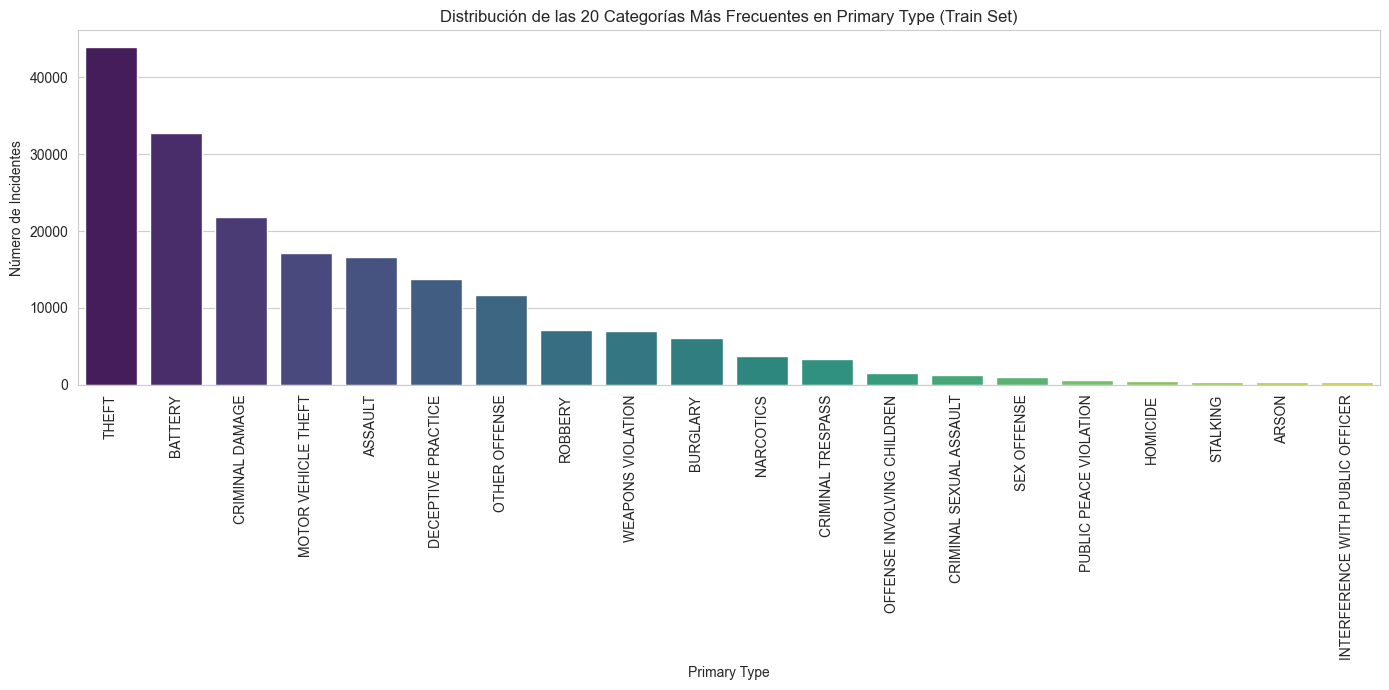

Nota: Se muestran solo las 20 categorías más frecuentes de un total de 31 para 'Primary Type'.


In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos SOLO el conjunto de entrenamiento para analizar el desbalance
columns_for_imbalance_analysis = ['Primary Type']

for col in columns_for_imbalance_analysis:
    print(f"\nAnalizando el desbalance de la columna: '{col}' (conjunto de entrenamiento)")

    # Contar la frecuencia de cada valor EN TRAIN
    value_counts = df_train[col].value_counts()

    # Mostrar el porcentaje de los 10 valores más frecuentes
    total_count = value_counts.sum()
    top_10_percent = (value_counts.head(10) / total_count) * 100
    print(f"Top 10 valores y su porcentaje en '{col}':\n{top_10_percent.round(2)}")

    # Crear un gráfico de barras para visualizar el desbalance
    plt.figure(figsize=(14, 7))
    # Limitar a los top 20 para evitar gráficos demasiado densos
    sns.barplot(x=value_counts.head(20).index, y=value_counts.head(20).values, palette='viridis')
    plt.title(f'Distribución de las 20 Categorías Más Frecuentes en {col} (Train Set)')
    plt.xlabel(col)
    plt.ylabel('Número de Incidentes')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # Imprimir una pequeña interpretación
    if len(value_counts) > 20:
        print(f"Nota: Se muestran solo las 20 categorías más frecuentes de un total de {len(value_counts)} para '{col}'.")

    # Añadir un separador para claridad
    print("="*80)

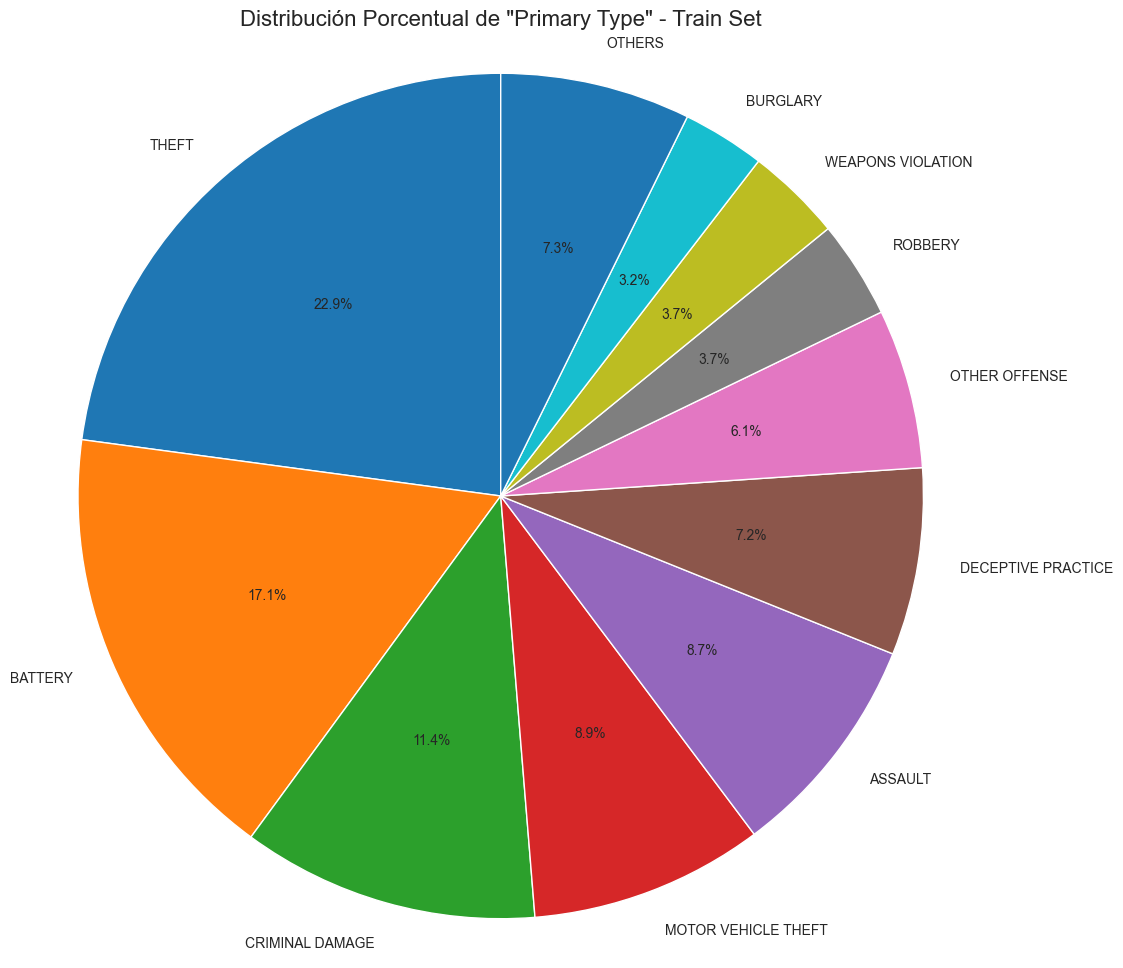

Entropía de Shannon: 3.1988 bits
Entropía máxima posible: 3.4594 bits
Entropía relativa: 92.47%


In [140]:
# Calcular el porcentaje de cada 'Primary Type' EN EL CONJUNTO DE ENTRENAMIENTO
primary_type_counts = df_train['Primary Type'].value_counts(normalize=True) * 100

# Seleccionar las top N categorías y agrupar el resto en 'Others'
# Podemos ajustar 'n_top_categories' según la claridad deseada
n_top_categories = 10
top_primary_types = primary_type_counts.head(n_top_categories)
other_primary_types = pd.Series([primary_type_counts.iloc[n_top_categories:].sum()], index=['OTHERS'])

# Combinar las categorías principales con 'Others'
plot_data = pd.concat([top_primary_types, other_primary_types])

# Crear el gráfico de torta
plt.figure(figsize=(12, 12))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución Porcentual de "Primary Type" - Train Set', fontsize=16)
plt.axis('equal') # Asegura que el gráfico de torta sea circular.
plt.show()


# Convertir porcentajes a probabilidades
probabilities = plot_data / 100

# Eliminar probabilidades 0 para evitar log(0)
probabilities = probabilities[probabilities > 0]

# Calcular entropía de Shannon
shannon_entropy = -np.sum(probabilities * np.log2(probabilities))

# Calcular entropía máxima posible
max_entropy = np.log2(len(probabilities))

# Entropía relativa
relative_entropy = shannon_entropy / max_entropy

print(f"Entropía de Shannon: {shannon_entropy:.4f} bits")
print(f"Entropía máxima posible: {max_entropy:.4f} bits")
print(f"Entropía relativa: {relative_entropy:.2%}")

### Conclusiones del Análisis de Desbalance

- Primary Type presenta desbalance natural: THEFT (22.9%), BATTERY (17.1%), CRIMINAL DAMAGE (11.4%) son las clases mayoritarias.
- Se evaluó agrupar clases minoritarias pero la entropía de Shannon solo mejoró 2%, por lo que se conservan las 31 clases originales.
- El desbalance refleja la distribución real de crímenes y se mantendrá para permitir que el modelo aprenda patrones realistas.

En el gráfico de torta vemos que hay un claro desbalance en la distribución de "Primary Type". Esto se debe a su naturaleza. Decidimos agrupar en "OTHERS" las categorías que tengan un peso menor al 6,5 %.

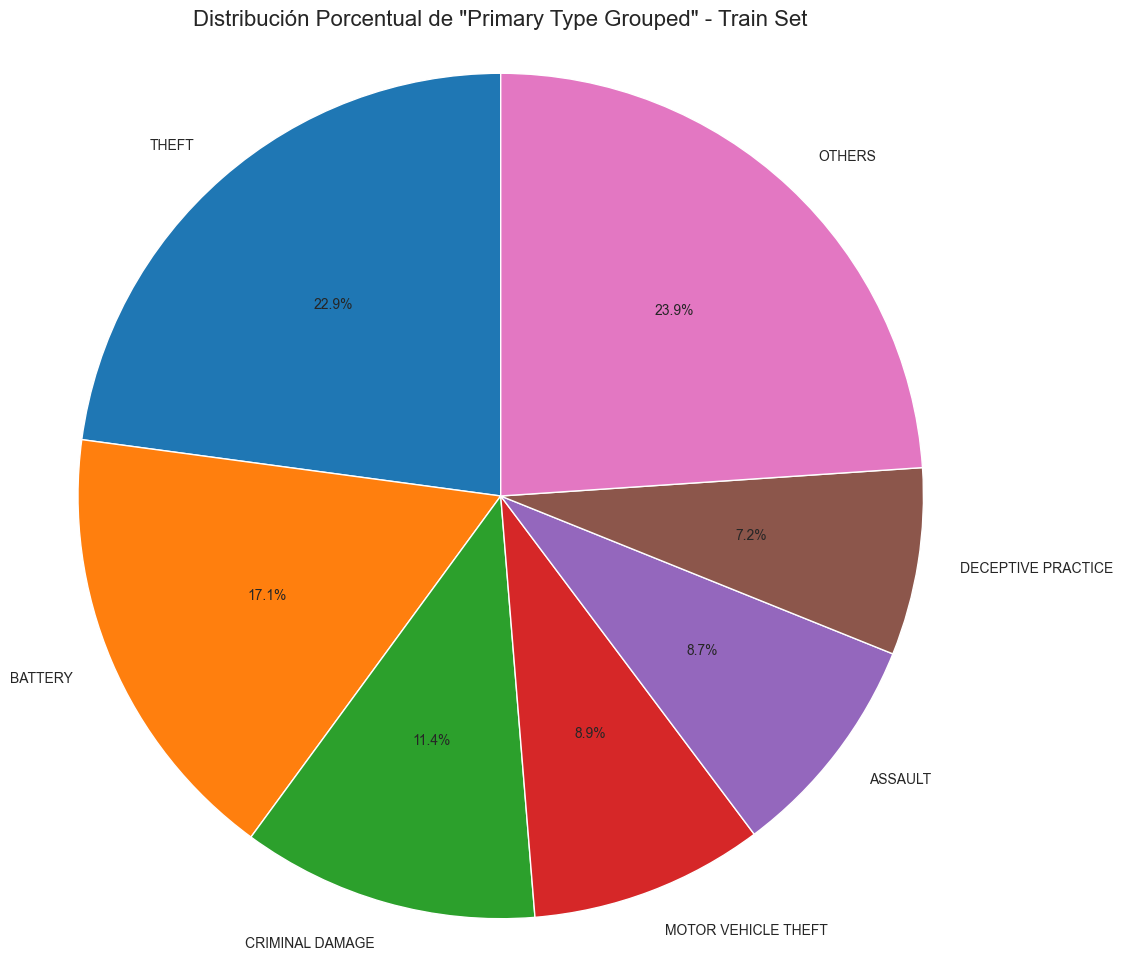

Entropía de Shannon para 'Primary Type Grouped': 2.6620 bits
Entropía máxima posible para 'Primary Type Grouped': 2.8074 bits
Entropía relativa para 'Primary Type Grouped': 94.82%

Nota: Este análisis fue temporal. No se modificó el conjunto de entrenamiento.


In [141]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Definir las categorías a agrupar explícitamente en 'OTHERS'
explicit_other_types_list = ['BURGLARY', 'WEAPONS VIOLATION', 'ROBBERY', 'OTHER OFFENSE']

# Creamos una columna TEMPORAL 'Primary Type Grouped' solo para comparar la entropía
# IMPORTANTE: trabajamos sobre una COPIA de df_train para no modificar el conjunto original
df_train_temp = df_train.copy()
df_train_temp['Primary Type Grouped'] = df_train_temp['Primary Type'].copy()

# Asignar las categorías explícitamente agrupadas a 'OTHERS'
df_train_temp.loc[df_train_temp['Primary Type Grouped'].isin(explicit_other_types_list), 'Primary Type Grouped'] = 'OTHERS'

# Calcular el porcentaje de cada 'Primary Type Grouped'
primary_type_grouped_counts = df_train_temp['Primary Type Grouped'].value_counts(normalize=True) * 100

# Definir el número de categorías principales a mostrar (excluyendo las ya agrupadas como 'OTHERS')
n_top_categories = 6

# Seleccionar las top N categorías, asegurando que 'OTHERS' no se considere como una de las top principales
top_primary_types_grouped = primary_type_grouped_counts[primary_type_grouped_counts.index != 'OTHERS'].head(n_top_categories)

# Calcular la suma de las categorías restantes no principales y añadirla a 'OTHERS'
# Si 'OTHERS' ya existe de la agrupación explícita, se suma, si no, se crea.
other_percentage_remaining = primary_type_grouped_counts[~primary_type_grouped_counts.index.isin(top_primary_types_grouped.index)].sum()

plot_data = pd.concat([top_primary_types_grouped, pd.Series([other_percentage_remaining], index=['OTHERS'])])

# Crear el gráfico de torta
plt.figure(figsize=(12, 12))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución Porcentual de "Primary Type Grouped" - Train Set', fontsize=16)
plt.axis('equal') # Asegura que el gráfico de torta sea circular.
plt.show()

# Convertir porcentajes a probabilidades
probabilities = plot_data / 100

# Eliminar probabilidades 0 para evitar log(0)
probabilities = probabilities[probabilities > 0]

# Calcular entropía de Shannon
shannon_entropy = -np.sum(probabilities * np.log2(probabilities))

# Calcular entropía máxima posible
max_entropy = np.log2(len(probabilities))

# Entropía relativa
relative_entropy = shannon_entropy / max_entropy

print(f"Entropía de Shannon para 'Primary Type Grouped': {shannon_entropy:.4f} bits")
print(f"Entropía máxima posible para 'Primary Type Grouped': {max_entropy:.4f} bits")
print(f"Entropía relativa para 'Primary Type Grouped': {relative_entropy:.2%}")

# No modificamos df_train, solo usamos df_train_temp para este análisis
print("\nNota: Este análisis fue temporal. No se modificó el conjunto de entrenamiento.")

Inicialmente se evaluó la posibilidad de agrupar las categorías de la variable Primary Type con el objetivo de reducir la cantidad de clases y analizar si esto mejoraba el balance de la variable target. Sin embargo, al comparar la entropía de Shannon antes y después del agrupamiento, se observó una diferencia reducida, cercana al 2%. Esto indica que el agrupamiento no generaba una mejora significativa en la distribución de clases.

Por este motivo, se decidió conservar las categorías originales de Primary Type, ya que mantienen mayor nivel de detalle e interpretabilidad sobre el tipo de crimen. Además, evitar el agrupamiento permite que el modelo trabaje con la clasificación original del dataset, sin introducir simplificaciones que podrían hacer perder información relevante.

### Creación de Features Temporales

Feature engineering temporal: derivamos variables a partir de `Date`. Son transformaciones por fila (deterministas), por lo que aplicarlas después del split no introduce data leakage.

Las features creadas son:
- **Day of week**: día de la semana (Monday, Tuesday, etc.)
- **Month**: mes del año (January, February, etc.)
- **Moment of day**: momento del día dividido en tres categorías (MORNING: 6-12h, AFTERNOON: 12-18h, NIGHT: 18-6h)

### Análisis de Features Temporales vs Primary Type

Justificación de la creación de las features temporales: analizamos si existe una relación entre el momento temporal del crimen y su tipo, lo que nos permitiría detectar patrones estacionales, semanales o diurnos en la criminalidad.

In [142]:
# Feature engineering temporal: derivamos variables a partir de 'Date'.
# Son transformaciones por fila (deterministas), por lo que aplicarlas
# después del split no introduce data leakage.

def get_moment_of_day(hour):
    if 6 <= hour < 12:
        return 'MORNING'
    elif 12 <= hour < 18:
        return 'AFTERNOON'
    else:
        return 'NIGHT'

def add_temporal_features(frame):
    frame = frame.copy()
    frame['Day of week'] = frame['Date'].dt.day_name()
    frame['Month'] = frame['Date'].dt.month_name()
    frame['Moment of day'] = frame['Date'].dt.hour.apply(get_moment_of_day)
    return frame.drop(columns=['Date'])

df_train = add_temporal_features(df_train)
df_test = add_temporal_features(df_test)

print("Nuevas columnas 'Day of week', 'Month', 'Moment of day' creadas y 'Date' eliminada (train y test).")
display(df_train.head())

Nuevas columnas 'Day of week', 'Month', 'Moment of day' creadas y 'Date' eliminada (train y test).


,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,Community Area,FBI Code,Day of week,Month,Moment of day
36674,0810,THEFT,OVER $500,RESIDENCE,False,False,1813,7.0,06,Sunday,November,MORNING
173558,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,APARTMENT,False,False,1934,6.0,11,Friday,April,MORNING
100453,0820,THEFT,$500 AND UNDER,RESIDENCE - PORCH / HALLWAY,False,False,631,44.0,06,Friday,August,AFTERNOON
35954,5002,OTHER OFFENSE,OTHER VEHICLE OFFENSE,STREET,False,False,2523,21.0,26,Monday,November,MORNING
164864,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,1135,27.0,14,Friday,May,NIGHT


Análisis 1: Distribución de Momento del Día por Primary Type (Top 10 Crímenes)


<Figure size 1400x800 with 0 Axes>

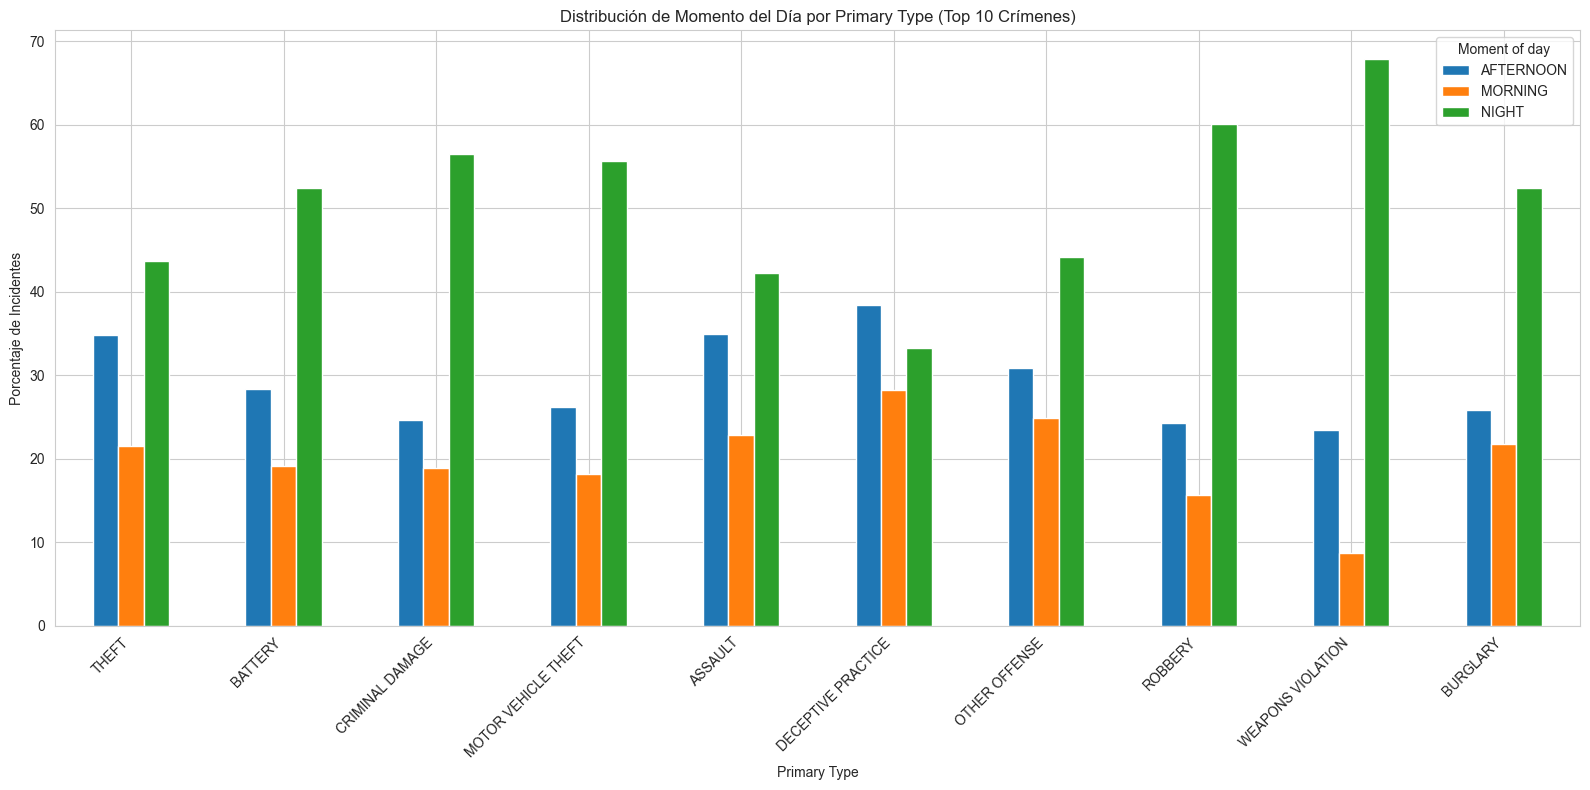


Análisis 2: Heatmap de Frecuencia de Crímenes por Día de la Semana (Top 10)


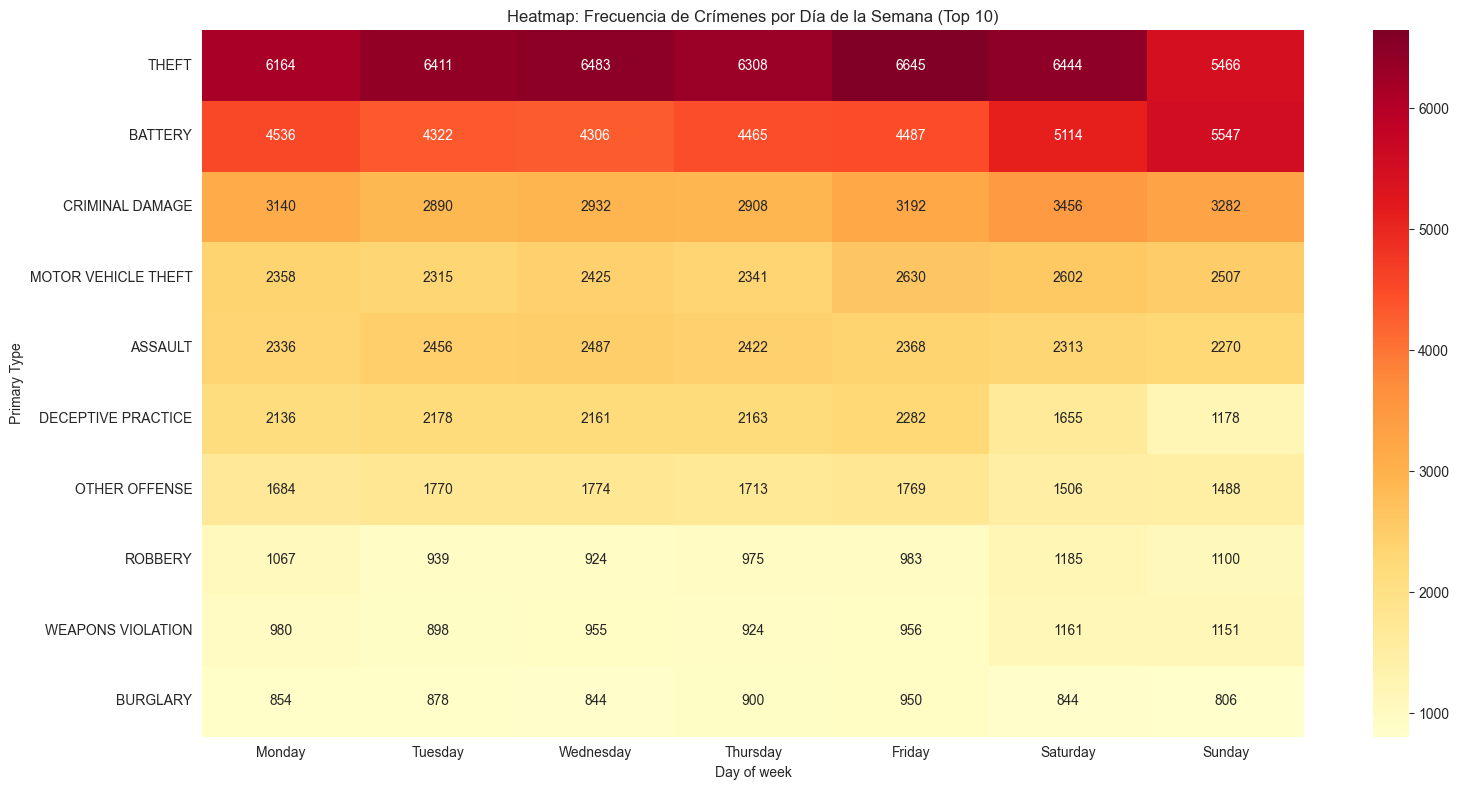


Análisis 3: Heatmap de Frecuencia de Crímenes por Mes (Top 8)


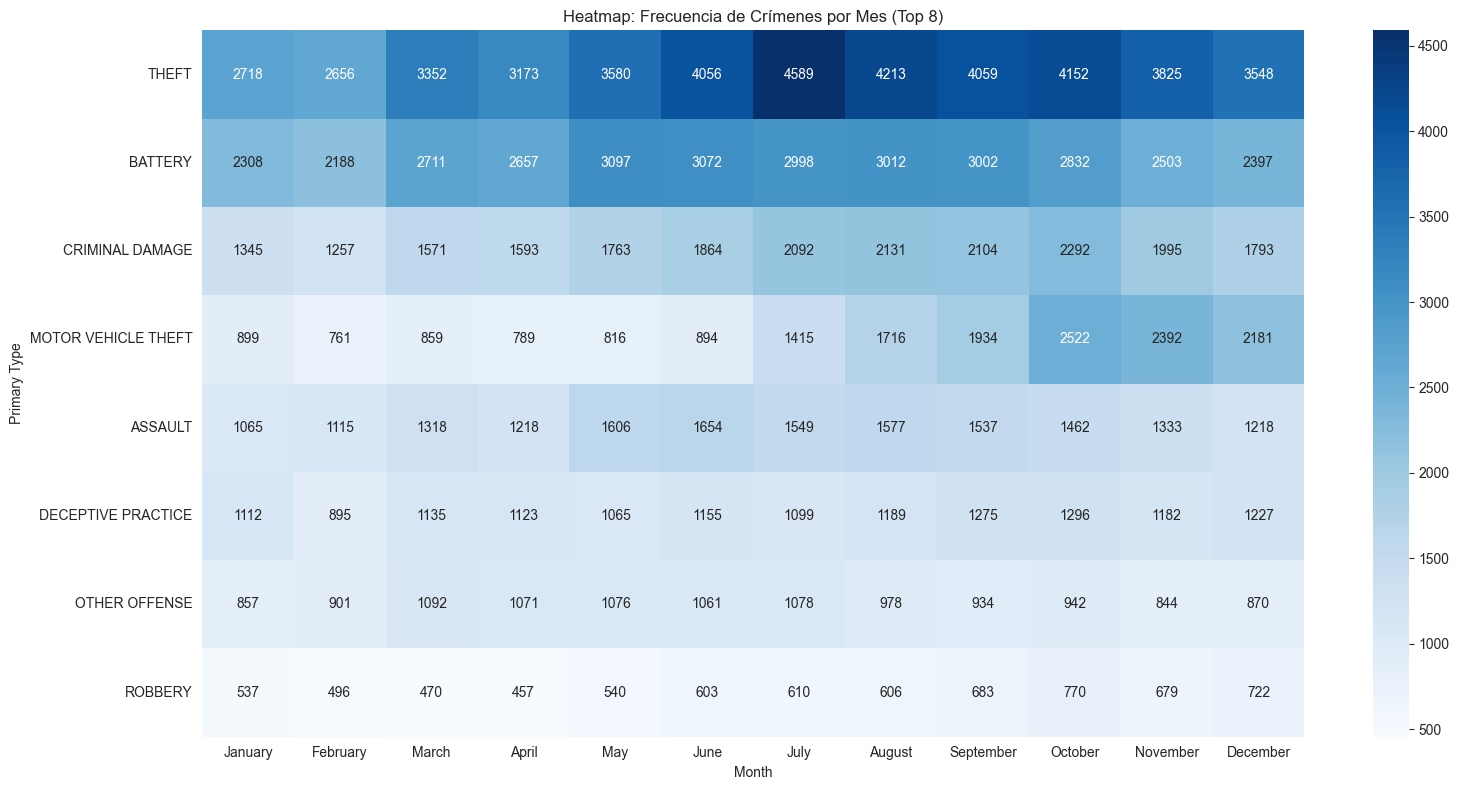


Análisis completado. Se observan patrones temporales en algunos tipos de crimen.


In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Análisis de Primary Type vs Moment of day
print("Análisis 1: Distribución de Momento del Día por Primary Type (Top 10 Crímenes)")
plt.figure(figsize=(14, 8))
ct_moment = pd.crosstab(df_train['Moment of day'], df_train['Primary Type'], normalize='columns') * 100
top_crimes = df_train['Primary Type'].value_counts().head(10).index
ct_moment[top_crimes].T.plot(kind='bar', stacked=False, figsize=(16, 8))
plt.title('Distribución de Momento del Día por Primary Type (Top 10 Crímenes)')
plt.xlabel('Primary Type')
plt.ylabel('Porcentaje de Incidentes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Moment of day')
plt.tight_layout()
plt.show()

# Análisis de Primary Type vs Day of week
print("\nAnálisis 2: Heatmap de Frecuencia de Crímenes por Día de la Semana (Top 10)")
plt.figure(figsize=(16, 8))
ct_dow = pd.crosstab(df_train['Day of week'], df_train['Primary Type'])
top_crimes_dow = df_train['Primary Type'].value_counts().head(10).index
ct_dow_top = ct_dow[top_crimes_dow]
# Ordenar días de la semana correctamente
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ct_dow_top = ct_dow_top.reindex(day_order)
sns.heatmap(ct_dow_top.T, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap: Frecuencia de Crímenes por Día de la Semana (Top 10)')
plt.xlabel('Day of week')
plt.ylabel('Primary Type')
plt.tight_layout()
plt.show()

# Análisis de Primary Type vs Month
print("\nAnálisis 3: Heatmap de Frecuencia de Crímenes por Mes (Top 8)")
plt.figure(figsize=(16, 8))
ct_month = pd.crosstab(df_train['Month'], df_train['Primary Type'])
top_crimes_month = df_train['Primary Type'].value_counts().head(8).index
ct_month_top = ct_month[top_crimes_month]
# Ordenar meses correctamente
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
ct_month_top = ct_month_top.reindex(month_order)
sns.heatmap(ct_month_top.T, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap: Frecuencia de Crímenes por Mes (Top 8)')
plt.xlabel('Month')
plt.ylabel('Primary Type')
plt.tight_layout()
plt.show()

print("\nAnálisis completado. Se observan patrones temporales en algunos tipos de crimen.")

### Conclusiones del Feature Engineering Temporal

- Se identifican patrones temporales claros: ciertos crímenes son más frecuentes en horarios/días/meses específicos.
- Las features temporales (Day of week, Month, Moment of day) aportan valor predictivo al modelo.
- Estos patrones reflejan comportamientos diferenciados según el tipo de crimen (ej: crímenes domésticos vs robos).

## 5. Reducción de dimensionalidad
✅ Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).

✅ Implementar la técnica de extracción de features vista en clase (PCA). Evaluar ventajas y desventajas de la reducción.

**Orden del pipeline:** primero la **selección por filtros** (sobre las variables categóricas originales), luego **removemos la feature redundante**, después **codificamos** solo las features seleccionadas y, finalmente, aplicamos **PCA** sobre esa matriz.

### 5.1 Selección de features por filtros

Los métodos de **filtro** evalúan cada feature por su relación estadística con el target (y entre sí), independientemente del modelo. Como las features son **categóricas**, usamos dos métricas apropiadas, calculadas **solo sobre el conjunto de entrenamiento**:

- **V de Cramér:** asociación entre dos variables categóricas en [0, 1] (con corrección de sesgo). La aplicamos **feature ↔ target** (relevancia) y **feature ↔ feature** (redundancia).
- **Mutual Information:** cuánta información aporta cada feature sobre el target; captura dependencias no lineales.

> `IUCR`, `Description` y `FBI Code` ya fueron descartadas en el EDA por *data leakage* / dependencia, así que el análisis se centra en las 8 features candidatas.

/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/2322881316.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cramers_target.values, y=cramers_target.index, palette='viridis')


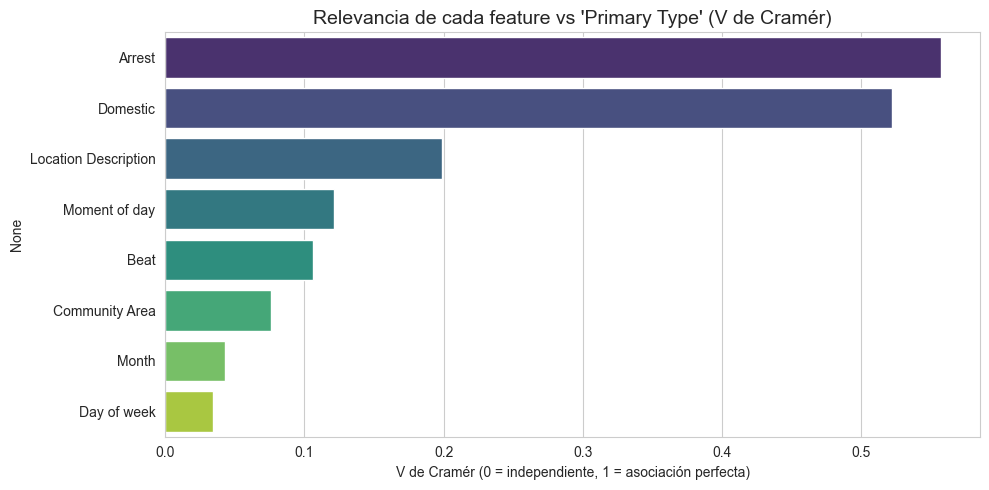

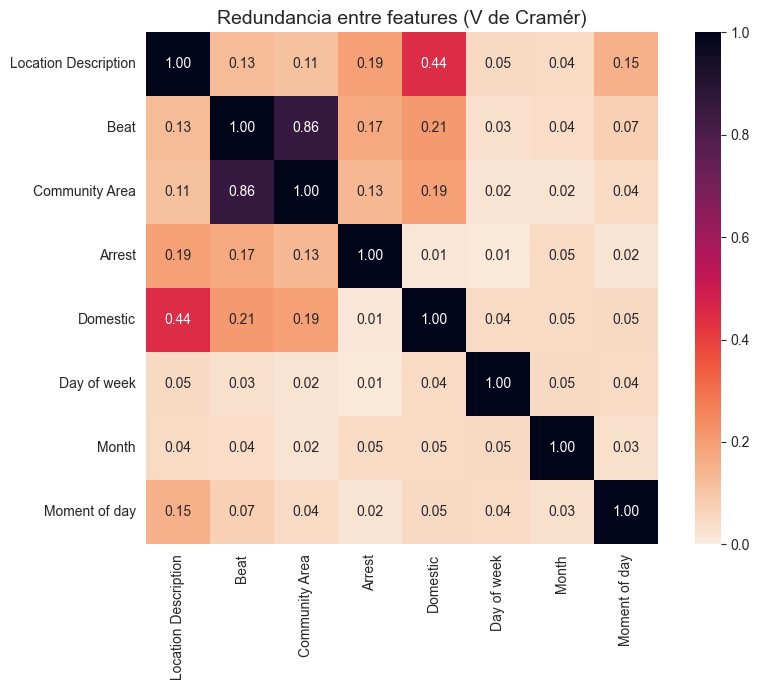

,V de Cramér vs target
Arrest,0.557
Domestic,0.522
Location Description,0.199
Moment of day,0.121
Beat,0.106
Community Area,0.076
Month,0.043
Day of week,0.035


In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")

def cramers_v(x, y):
    # V de Cramér con corrección de sesgo (Bergsma) para dos series categóricas
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

# Features categóricas candidatas (aún incluye Community Area: decidiremos sobre ella)
feature_cols = ['Location Description', 'Beat', 'Community Area', 'Arrest', 'Domestic',
                'Day of week', 'Month', 'Moment of day']
target = 'Primary Type'

X_cat = df_train[feature_cols].astype(str)
y_cat = df_train[target].astype(str)

# Relevancia: V de Cramér de cada feature contra el target
cramers_target = pd.Series({c: cramers_v(X_cat[c], y_cat) for c in feature_cols}).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=cramers_target.values, y=cramers_target.index, palette='viridis')
plt.title("Relevancia de cada feature vs 'Primary Type' (V de Cramér)", fontsize=14)
plt.xlabel("V de Cramér (0 = independiente, 1 = asociación perfecta)")
plt.tight_layout(); plt.show()

# Redundancia: matriz de V de Cramér entre features
n = len(feature_cols)
redundancy = pd.DataFrame(np.eye(n), index=feature_cols, columns=feature_cols)
for i in range(n):
    for j in range(i + 1, n):
        v = cramers_v(X_cat[feature_cols[i]], X_cat[feature_cols[j]])
        redundancy.iloc[i, j] = redundancy.iloc[j, i] = v
plt.figure(figsize=(9, 7))
sns.heatmap(redundancy, annot=True, fmt='.2f', cmap='rocket_r', vmin=0, vmax=1, square=True)
plt.title("Redundancia entre features (V de Cramér)", fontsize=14)
plt.tight_layout(); plt.show()

display(cramers_target.to_frame("V de Cramér vs target").round(3))

/var/folders/jp/jjzrzfs55qs_11py_qkz4h8c0000gn/T/ipykernel_71453/902092265.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette='magma')


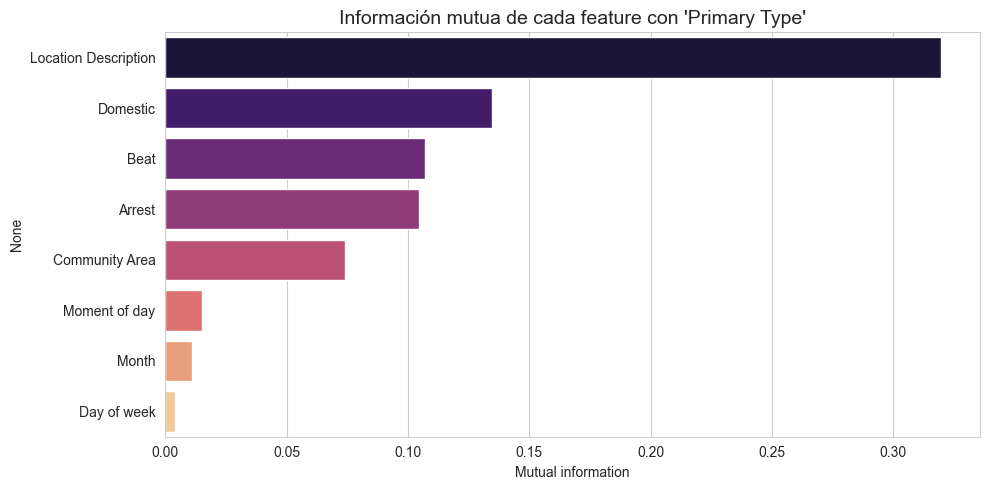

,V de Cramér,Mutual information
Arrest,0.557,0.105
Domestic,0.522,0.135
Location Description,0.199,0.320
Moment of day,0.121,0.015
Beat,0.106,0.107
Community Area,0.076,0.074
Month,0.043,0.011
Day of week,0.035,0.004


In [145]:
from sklearn.feature_selection import mutual_info_classif

X_le = X_cat.apply(lambda s: s.astype('category').cat.codes)
mi = mutual_info_classif(X_le, y_cat, discrete_features=True, random_state=42)
mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='magma')
plt.title("Información mutua de cada feature con 'Primary Type'", fontsize=14)
plt.xlabel("Mutual information"); plt.tight_layout(); plt.show()

comparativa = pd.concat([
    cramers_target.rename("V de Cramér"),
    mi_series.rename("Mutual information"),
], axis=1).round(3)
display(comparativa)

#### Conclusiones de la selección por filtros

- **Relevancia:** `Arrest`, `Domestic` y `Location Description` son las features más informativas sobre el tipo de crimen; las temporales (`Month`, `Day of week`) aportan una señal muy débil pero su costo dimensional es bajo, así que las conservamos.
- **Redundancia:** `Beat` y `Community Area` tienen una **V de Cramér ≈ 0,86** — son casi la misma información geográfica (cada `Beat` cae dentro de una única `Community Area`).
- **Decisión:** **eliminamos `Community Area`** y conservamos `Beat` (más granular —283 vs 77 categorías— y la determina). Quedan **7 features** + el target.

### 5.2 Aplicación de la selección

Como `Community Area` resultó redundante con `Beat`, **no la incluimos entre las features a codificar**. No la borramos de `df_train`/`df_test` (así la celda de filtros 5.1 sigue siendo reproducible aunque se re-ejecute); simplemente queda fuera de la lista de features que se codifican y entran a PCA.

In [146]:
# Selección aplicada: Community Area queda EXCLUIDA de las features (redundante con Beat).
# No mutamos df_train/df_test para que 5.1 siga siendo reproducible al re-ejecutar.
selected_features = ['Location Description', 'Beat', 'Arrest', 'Domestic',
                     'Day of week', 'Month', 'Moment of day']

print(f"Features seleccionadas ({len(selected_features)}): {selected_features}")
print("Community Area se excluye de la codificación por redundancia con Beat (Cramér ~ 0,86).")

Features seleccionadas (7): ['Location Description', 'Beat', 'Arrest', 'Domestic', 'Day of week', 'Month', 'Moment of day']
Community Area se excluye de la codificación por redundancia con Beat (Cramér ~ 0,86).


### 5.3 Codificación de las features seleccionadas

Para que los modelos procesen las variables categóricas, las convertimos a numéricas con dos técnicas según su cardinalidad. **Todos los encoders se ajustan solo con train** (sin *data leakage*) y **no codificamos el target** (`Primary Type` se mantiene aparte como `y`).

**Binary Encoding** — para **alta cardinalidad** (`Location Description` con 136 categorías, `Beat` con 283). Mapea cada categoría a su representación **binaria**, generando `ceil(log2(nº categorías))` columnas por feature (8 y 9 respectivamente). Ventajas: evita la explosión del One-Hot (~420 columnas), no tiene colisiones y maneja categorías nuevas en test.

**Ordinal Encoding** — para **baja cardinalidad u orden natural**: `Day of week`, `Month`, `Moment of day` (orden temporal) y `Arrest`, `Domestic` (booleanas).

In [147]:
from category_encoders import BinaryEncoder

# Binary Encoding para las features de alta cardinalidad (SIN el target)
binary_encoding_features = ['Location Description', 'Beat']

binary_encoder = BinaryEncoder(cols=binary_encoding_features, return_df=True)
binary_encoder.fit(df_train[binary_encoding_features])  # fit solo en train

df_train_binary_encoded = binary_encoder.transform(df_train[binary_encoding_features])
df_test_binary_encoded = binary_encoder.transform(df_test[binary_encoding_features])

print("Binary Encoding:")
print(f"  Train: {df_train_binary_encoded.shape}  |  Test: {df_test_binary_encoded.shape}")
print(f"  Columnas: {df_train_binary_encoded.columns.tolist()}")
display(df_train_binary_encoded.head())

Binary Encoding:
  Train: (192035, 17)  |  Test: (48009, 17)
  Columnas: ['Location Description_0', 'Location Description_1', 'Location Description_2', 'Location Description_3', 'Location Description_4', 'Location Description_5', 'Location Description_6', 'Location Description_7', 'Beat_0', 'Beat_1', 'Beat_2', 'Beat_3', 'Beat_4', 'Beat_5', 'Beat_6', 'Beat_7', 'Beat_8']


,Location Description_0,Location Description_1,Location Description_2,Location Description_3,Location Description_4,Location Description_5,Location Description_6,Location Description_7,Beat_0,Beat_1,Beat_2,Beat_3,Beat_4,Beat_5,Beat_6,Beat_7,Beat_8
36674,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
173558,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
100453,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1
35954,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
164864,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1


In [148]:
from sklearn.preprocessing import OrdinalEncoder

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
moment_order = ['MORNING', 'AFTERNOON', 'NIGHT']

ordinal_features = ['Day of week', 'Month', 'Moment of day', 'Arrest', 'Domestic']
ordinal_encoder = OrdinalEncoder(
    categories=[day_order, month_order, moment_order, [False, True], [False, True]],
    handle_unknown='use_encoded_value', unknown_value=-1)
ordinal_encoder.fit(df_train[ordinal_features])  # fit solo en train

df_train_ordinal = pd.DataFrame(
    ordinal_encoder.transform(df_train[ordinal_features]),
    columns=[f'ord_{c}' for c in ordinal_features], index=df_train.index)
df_test_ordinal = pd.DataFrame(
    ordinal_encoder.transform(df_test[ordinal_features]),
    columns=[f'ord_{c}' for c in ordinal_features], index=df_test.index)

print("Ordinal Encoding:")
print(f"  Train: {df_train_ordinal.shape}  |  Test: {df_test_ordinal.shape}")
display(df_train_ordinal.head())

Ordinal Encoding:
  Train: (192035, 5)  |  Test: (48009, 5)


,ord_Day of week,ord_Month,ord_Moment of day,ord_Arrest,ord_Domestic
36674,6.0,10.0,0.0,0.0,0.0
173558,4.0,3.0,0.0,0.0,0.0
100453,4.0,7.0,1.0,0.0,0.0
35954,0.0,10.0,0.0,0.0,0.0
164864,4.0,4.0,2.0,0.0,0.0


In [149]:
# Combinar features codificadas (cada conjunto con SU PROPIO binary encoding -> sin fuga)
df_train_encoded = pd.concat([
    df_train_binary_encoded.reset_index(drop=True),
    df_train_ordinal.reset_index(drop=True),
], axis=1)
df_test_encoded = pd.concat([
    df_test_binary_encoded.reset_index(drop=True),
    df_test_ordinal.reset_index(drop=True),
], axis=1)

# El target se mantiene aparte (no se codifica dentro de las features)
y_train = df_train[target].reset_index(drop=True)
y_test = df_test[target].reset_index(drop=True)

print("Dataset final codificado (solo features):")
print(f"  X_train: {df_train_encoded.shape}  |  X_test: {df_test_encoded.shape}")
print(f"  Columnas ({len(df_train_encoded.columns)}): {df_train_encoded.columns.tolist()}")
display(df_train_encoded.head())

Dataset final codificado (solo features):
  X_train: (192035, 22)  |  X_test: (48009, 22)
  Columnas (22): ['Location Description_0', 'Location Description_1', 'Location Description_2', 'Location Description_3', 'Location Description_4', 'Location Description_5', 'Location Description_6', 'Location Description_7', 'Beat_0', 'Beat_1', 'Beat_2', 'Beat_3', 'Beat_4', 'Beat_5', 'Beat_6', 'Beat_7', 'Beat_8', 'ord_Day of week', 'ord_Month', 'ord_Moment of day', 'ord_Arrest', 'ord_Domestic']


,Location Description_0,Location Description_1,Location Description_2,Location Description_3,Location Description_4,Location Description_5,Location Description_6,Location Description_7,Beat_0,Beat_1,...,Beat_4,Beat_5,Beat_6,Beat_7,Beat_8,ord_Day of week,ord_Month,ord_Moment of day,ord_Arrest,ord_Domestic
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,6.0,10.0,0.0,0.0,0.0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,4.0,3.0,0.0,0.0,0.0
2,0,0,0,0,0,0,1,1,0,0,...,0,0,0,1,1,4.0,7.0,1.0,0.0,0.0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0.0,10.0,0.0,0.0,0.0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,1,4.0,4.0,2.0,0.0,0.0


#### Conclusiones de la codificación

- **22 features numéricas** por observación: 17 de Binary Encoding (`Location Description` → 8, `Beat` → 9) + 5 de Ordinal Encoding.
- **Sin data leakage:** todos los encoders se ajustaron solo con train, y train/test usan cada uno su propia transformación.
- **El target queda separado** en `y_train` / `y_test` (no se codifica dentro de `X`).
- `df_train_encoded` / `df_test_encoded` quedan listos para PCA y para el modelado posterior.

### 5.4 Extracción de features: PCA

A diferencia de la selección (que *elige* features originales), PCA **construye** nuevas variables —las componentes principales— como combinaciones lineales de las originales, ordenadas por la varianza que capturan. Trabajamos sobre **la matriz ya codificada** (`df_train_encoded`), **estandarizada** y ajustada **solo con train**.

Features codificadas para PCA: 22 columnas
Componentes necesarias por umbral de varianza: {'50%': 10, '80%': 16, '90%': 19, '95%': 20}


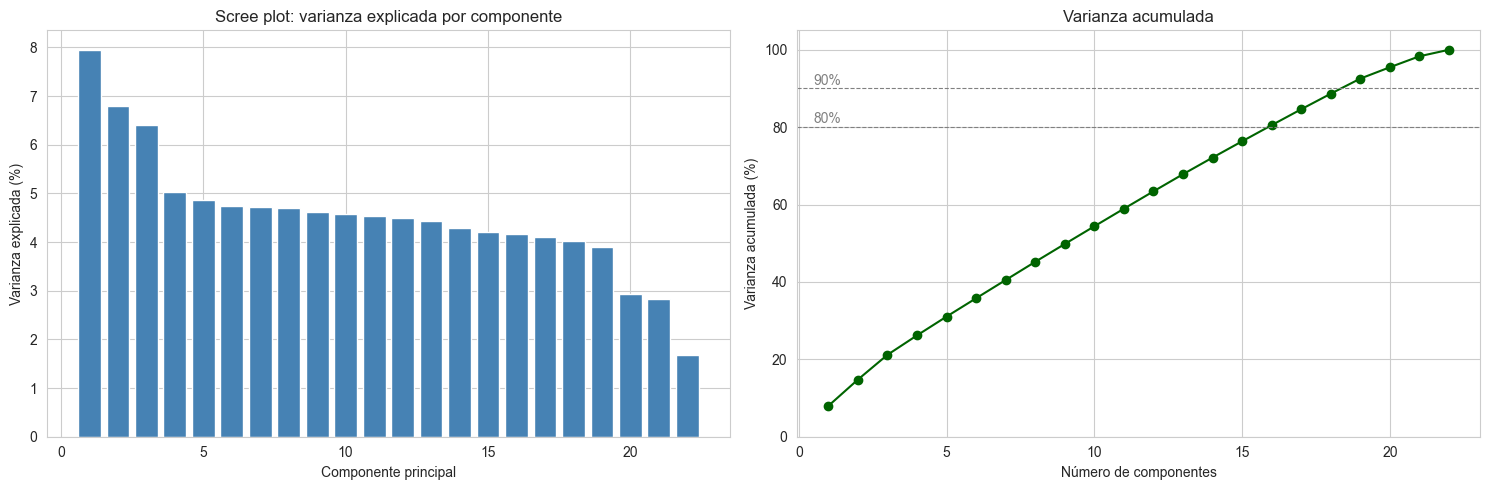

In [150]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train_pca = df_train_encoded.copy()   # ya no contiene target ni Community Area
print(f"Features codificadas para PCA: {X_train_pca.shape[1]} columnas")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)

pca_full = PCA(random_state=42).fit(X_train_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

umbral_resumen = {f"{t:.0%}": int(np.argmax(cumulative >= t) + 1) for t in [0.5, 0.8, 0.9, 0.95]}
print("Componentes necesarias por umbral de varianza:", umbral_resumen)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.bar(range(1, len(explained) + 1), explained * 100, color='steelblue')
ax1.set_title("Scree plot: varianza explicada por componente")
ax1.set_xlabel("Componente principal"); ax1.set_ylabel("Varianza explicada (%)")
ax2.plot(range(1, len(cumulative) + 1), cumulative * 100, marker='o', color='darkgreen')
for t in [80, 90]:
    ax2.axhline(t, ls='--', color='grey', lw=0.8); ax2.text(0.5, t + 1, f"{t}%", color='grey')
ax2.set_title("Varianza acumulada"); ax2.set_xlabel("Número de componentes")
ax2.set_ylabel("Varianza acumulada (%)"); ax2.set_ylim(0, 105)
plt.tight_layout(); plt.show()

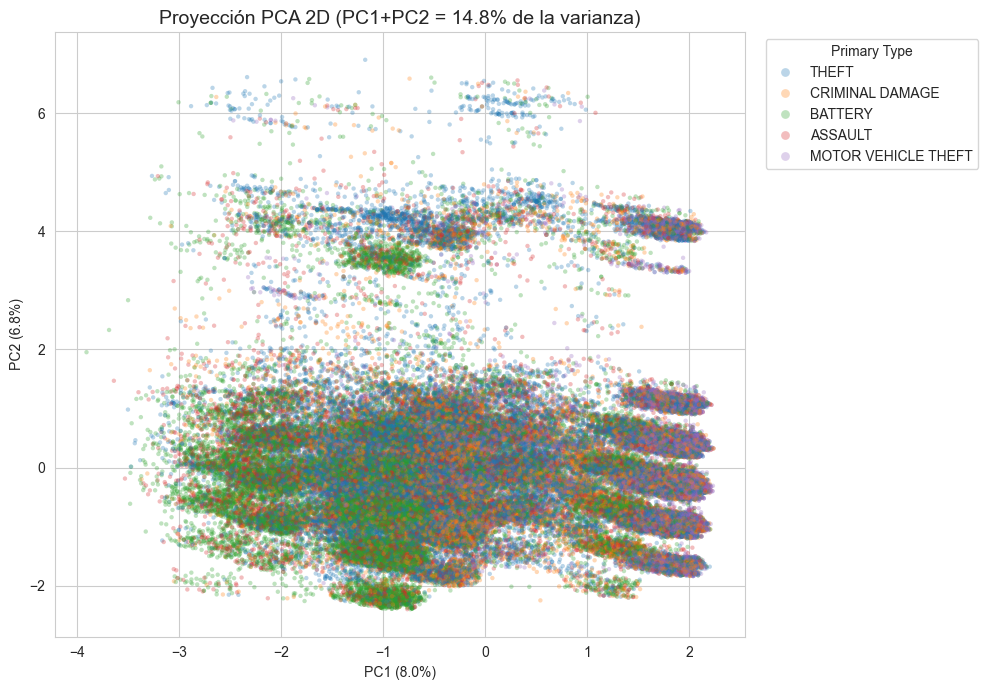

In [151]:
# Proyección sobre las 2 primeras componentes, coloreada por las clases más frecuentes
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(X_train_scaled)

top5 = y_train.value_counts().nlargest(5).index
mask = y_train.isin(top5).to_numpy()
var2d = pca_2d.explained_variance_ratio_

plt.figure(figsize=(10, 7))
sns.scatterplot(x=coords[mask, 0], y=coords[mask, 1],
                hue=y_train[mask].to_numpy(), s=10, alpha=0.3, linewidth=0)
plt.title(f"Proyección PCA 2D (PC1+PC2 = {var2d.sum():.1%} de la varianza)", fontsize=14)
plt.xlabel(f"PC1 ({var2d[0]:.1%})"); plt.ylabel(f"PC2 ({var2d[1]:.1%})")
plt.legend(title='Primary Type', markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

#### Conclusiones de PCA: ventajas y desventajas

Sobre las 22 features codificadas, el **espectro de varianza es muy plano**: la primera componente explica solo ~8 % y hacen falta **19 de las 22 componentes para alcanzar el 90 %**. La proyección 2D retiene apenas ~15 % de la varianza y no separa las clases. Es decir, **PCA casi no reduce la dimensionalidad** en este dataset.

La causa es la naturaleza del dato: las features son categóricas y —según los filtros— **mayormente independientes entre sí** (la única redundancia fuerte, `Beat`↔`Community Area`, ya la resolvimos eliminando `Community Area`). Sin variables continuas correlacionadas, no hay pocas direcciones dominantes que comprimir.

**Desventajas (y por qué pesan aca):**
- **Compresión nula:** pasar de 22 a 19 dimensiones no aporta.
- **Pérdida de interpretabilidad:** las componentes son combinaciones lineales de columnas binarias, sin lectura directa.

**Conclusión.** La reducción de dimensionalidad efectiva vino de la **selección por filtros** (descartar `IUCR`/`Description`/`FBI Code` por leakage/dependencia y `Community Area` por redundancia), no de la extracción con PCA. PCA queda **implementado y evaluado**, pero **no se adopta** en el pipeline final.